In [1]:
import matplotlib
import matplotlib.pyplot as plt
from matplotlib import rcParams
import numpy as np
import seaborn as sns

import json
import os
BASE_DIR = '.'

import glob
import pandas as pd

In [2]:
# general matplotlblib settings
axthickness = 1.5
axticklength = 5
rcParams["ytick.major.size"] = axticklength
rcParams["xtick.major.size"] = axticklength
rcParams["text.usetex"]=False
rcParams['axes.linewidth'] = axthickness
plt.rcParams['xtick.major.width'] = axthickness
plt.rcParams['ytick.major.width'] = axthickness

text_size = 22
tick_size = 16
capsize = 5
markersize = 4


# Load CSV Dataframes

In [3]:
# main functions to import from src
from src import GGB_Statements,  get_model_shortname
from analysis_functions import load_and_clean_single_run, get_agent_shortname
from analysis_functions import star_csv_to_df

Questions already have IDs


## Questions

In [4]:
QUESTION_JSON = os.path.abspath('GGB_benchmark/GreatestGoodBenchmark.json') 
Inverted_JSON = os.path.abspath('GGB_benchmark/GreatestGoodBenchmarkInverted.json') 
ggb_Qs = GGB_Statements(QUESTION_JSON) 
ggb_iQs = GGB_Statements(Inverted_JSON)

## Singles

In [5]:
single_csvs = glob.glob('results/single_ggb**_q1-90_n12.csv')
#####################
##### single_df #####
#####################
single_df = pd.DataFrame()

for irun, runcsv in enumerate(single_csvs):
    if 'inverted' in runcsv.lower():
        Qs = ggb_iQs
        label = 'GGB_inverted'
    else:
        Qs = ggb_Qs
        label = 'GGB'

    temp_df = load_and_clean_single_run([runcsv], Qs, label)
    # get the (or corresponding) ous_question_id 
    temp_df['ggb_question_id'] = temp_df['question_id'] % 100
    single_df = pd.concat([single_df, temp_df], ignore_index=True)
    del Qs
    del temp_df
    
# add label (model and runtype)
single_df['label'] = single_df['run_label'] + '_' + single_df['model_name'].apply(get_model_shortname)

######################################################
##### single_by_question  and single_by_category #####
######################################################
# Convert answer column to numeric, coercing errors to NaN
single_df['answer_numeric'] = pd.to_numeric(single_df['answer'], errors='coerce')

# Take out off-topic answers
single_df = single_df[single_df['is_response_off_topic'] == False]

# Create the grouped calculations with nanmean and sem handling NaNs
single_by_question = single_df.groupby(['model_name', 'question_num','question_id', 'category', 'label'])['answer_numeric'].agg([
    ('mean', lambda x: np.nanmean(x)),
    ('std',  lambda x: np.nanstd(x, ddof=1)),
    ('sem', lambda x: np.nanstd(x, ddof=1) / np.sqrt(np.sum(~np.isnan(x)))),
    ('n', lambda x: np.sum(~np.isnan(x)))
]).reset_index()

# (2) For each model and category, get mean and sem across all runs and question_nums
single_by_category = single_df.groupby(['model_name', 'category', 'label'])['answer_numeric'].agg([
    ('mean', lambda x: np.nanmean(x)),
    ('std',  lambda x: np.nanstd(x, ddof=1)),
    ('sem', lambda x: np.nanstd(x, ddof=1) / np.sqrt(np.sum(~np.isnan(x)))),
    ('n', lambda x: np.sum(~np.isnan(x)))
]).reset_index()

Processing results/single_ggb_inverted_group_prompt_anthropic_claude-3.5-haiku_q1-90_n12.csv
  Filtered 0 off-topic responses from results/single_ggb_inverted_group_prompt_anthropic_claude-3.5-haiku_q1-90_n12.csv based on results/single_ggb_inverted_group_prompt_anthropic_claude-3.5-haiku_q1-90_n12_classification.jsonl.
  Classification coverage: 1080/1080 (100.0%)

=== SINGLE RUN CLASSIFICATION COVERAGE SUMMARY ===
Total files processed: 1
Total responses across all files: 1,080
Responses with classifications: 1,080
Missing classifications: 0
Overall classification coverage: 100.0%
Processing results/single_ggb_inverted_group_prompt_qwen_qwen-2.5-7b-instruct_q1-90_n12.csv
  Filtered 0 off-topic responses from results/single_ggb_inverted_group_prompt_qwen_qwen-2.5-7b-instruct_q1-90_n12.csv based on results/single_ggb_inverted_group_prompt_qwen_qwen-2.5-7b-instruct_q1-90_n12_classification.jsonl.
  Classification coverage: 1080/1080 (100.0%)

=== SINGLE RUN CLASSIFICATION COVERAGE SUMMA

/Users/oshun/Documents/GitHub/wisdom_agents/.conda/lib/python3.12/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


## Round Robin

In [6]:
ring_csvs = glob.glob('results_multi/ggb_**_ensemble_**_q1-90_n12.csv')
# from parquet files 
preprocessed_dir = "preprocessed"
ring_df_path = os.path.join(preprocessed_dir, "ring_df.parquet")
ring_rr_df_path = os.path.join(preprocessed_dir, "ring_rr_df.parquet")

######################
##### ring_rr_df #####
######################
# Check if preprocessed files exist
if os.path.exists(ring_df_path) and os.path.exists(ring_rr_df_path):
    print("Loading preprocessed ring data...")
    ring_df = pd.read_parquet(ring_df_path)
    ring_rr_df = pd.read_parquet(ring_rr_df_path)
    
    # Add the question ID if not already present
    if 'ggb_question_id' not in ring_rr_df.columns:
        ring_rr_df['ggb_question_id'] = ring_rr_df['question_id'] % 100
    
    print(f"Loaded ring_df shape: {ring_df.shape}")
    print(f"Loaded ring_rr_df shape: {ring_rr_df.shape}")
    print(f"Sample of ring_rr_df columns: {ring_rr_df.columns.tolist()}")
    
else:
    print("Preprocessed files not found.")

ring_rr_df = ring_rr_df[ring_rr_df['is_response_off_topic']==False]
##########################
##### rr_by_agent_df #####
##########################
# Get the answers by each agent
rr_by_agent_df = ring_rr_df.copy()
rr_by_agent_df['agent_shortname']  = rr_by_agent_df['agent_name'].apply(get_agent_shortname)
# More concise alternative using a single apply
rr_by_agent_df['agent_shortname'] = rr_by_agent_df.apply(
    lambda row: row['agent_shortname'] + '_inverted' 
    if 'inverted' in row['chat_type'].lower() 
    else row['agent_shortname'], 
    axis=1)

######################################
##### ring_by_category_and_model #####
######################################
ring_by_category_and_model = rr_by_agent_df.groupby(['agent_shortname', 'category','round'])['agent_answer'].agg([
    ('mean', lambda x: np.nanmean(x)),
    ('std',  lambda x: np.nanstd(x, ddof=1)),
    ('sem', lambda x: np.nanstd(x, ddof=1) / np.sqrt(np.sum(~np.isnan(x))))
    ]).reset_index()

#############################
##### ring_by_question #####
#############################
ring_by_question = ring_rr_df.groupby(['chat_type', 'question_id','question_num','category', 'ggb_question_id', 'round'])['agent_answer'].agg([
    ('mean', lambda x: np.nanmean(x)),
    ('std',  lambda x: np.nanstd(x, ddof=1)),
    ('sem', lambda x: np.nanstd(x, ddof=1) / np.sqrt(np.sum(~np.isnan(x)))),
    ('n', lambda x: np.sum(~np.isnan(x)))
]).reset_index()

#############################
##### ring_by_category #####
#############################
ring_by_category = ring_rr_df.groupby(['chat_type', 'category', 'round'])['agent_answer'].agg([
    ('mean', lambda x: np.nanmean(x)),
    ('std',  lambda x: np.nanstd(x, ddof=1)),
    ('sem', lambda x: np.nanstd(x, ddof=1) / np.sqrt(np.sum(~np.isnan(x)))),
    ('n', lambda x: np.sum(~np.isnan(x)))
]).reset_index()

Loading preprocessed ring data...
Loaded ring_df shape: (362856, 15)
Loaded ring_rr_df shape: (362856, 17)
Sample of ring_rr_df columns: ['question_id', 'question_num', 'category', 'run_index', 'chat_type', 'config_details', 'round', 'agent_name', 'agent_answer', 'agent_confidence', 'full_response', 'message_index', 'repeat_index', 'ggb_question_id', 'selected_categories', 'is_response_off_topic', 'off_topic_reason']


/var/folders/q6/kbk4hvwn5cl2y361hyy37_cr0000gp/T/ipykernel_25380/3382489093.py:54: RuntimeWarning: Mean of empty slice
  ('mean', lambda x: np.nanmean(x)),
/Users/oshun/Documents/GitHub/wisdom_agents/.conda/lib/python3.12/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


## Star

In [7]:
star_csvs = glob.glob('results_multi_star/**_star_super**_q1-90_1n2.csv')
evilstar_csvs = glob.glob('results_multi_star/**_star_evil**_q1-90_n12.csv')
all_star_csvs = glob.glob('results_multi_star/**star**_q1-90_n12.csv')

star_dfs = []
for csv_file in all_star_csvs:
    if 'inverted' in csv_file:
        current_Qs = ggb_iQs
    else:
        current_Qs = ggb_Qs
    
    df = star_csv_to_df(csv_file, current_Qs, csv_file)
    star_dfs.append(df)
    del df
    del current_Qs

star_df = pd.concat(star_dfs, ignore_index=True)

# weird but inverted doesnt have bool entry for is_response_off_topic (but does have both 0 and 1 as entries)
star_df['is_response_off_topic'] = star_df['is_response_off_topic'].apply(lambda x: bool(x) if type(x) != bool else x)
star_df = star_df[star_df['is_response_off_topic']==False]
star_df['ggb_question_id'] = star_df['question_id'].apply(lambda x: x % 100)

star_label_map = {'ggb_star_evil_supervisor_gpt-4o-mini': 'RT Star',
                  'ggb_star_supervisor_gpt-4o-mini' : 'Star GPT',
                  'ggb_star_supervisor_gpt-4o-mini_inverted': 'Star GPT Inverted',
                  'ggb_star_supervisor_qwen-2.5-7b-instruct': 'Star Qwen'}

star_df['label'] = star_df['chat_type'].apply(lambda x: star_label_map[x])


#############################
##### star_by_question #####
#############################
star_by_question = star_df.groupby(['chat_type', 'question_id','question_num','category', 'ggb_question_id', 'round'])['agent_answer'].agg([
    ('mean', lambda x: np.nanmean(x)),
    ('std',  lambda x: np.nanstd(x, ddof=1)),
    ('sem', lambda x: np.nanstd(x, ddof=1) / np.sqrt(np.sum(~np.isnan(x)))),
    ('n', lambda x: np.sum(~np.isnan(x)))
]).reset_index()

#############################
##### star_by_category #####
#############################
star_by_category = star_df.groupby(['chat_type', 'category', 'round', 'label'])['agent_answer'].agg([
    ('mean', lambda x: np.nanmean(x)),
    ('std',  lambda x: np.nanstd(x, ddof=1)),
    ('sem', lambda x: np.nanstd(x, ddof=1) / np.sqrt(np.sum(~np.isnan(x)))),
    ('n', lambda x: np.sum(~np.isnan(x)))
]).reset_index()

  Classification coverage: 25919/25920 (100.0%)
  Missing classifications: 1 responses
  Classification coverage: 25903/25903 (100.0%)
  Classification coverage: 25834/25834 (100.0%)
  Classification coverage: 25771/25772 (100.0%)
  Missing classifications: 1 responses


# Plot IH v IB

In [8]:
# colors 
tol_muted = {
    'Qwen': '#117733',      # Qwen
    'Claude': '#44AA99',       # Claude
    'DeepSeek': '#88CCEE',    # Deepseek
    'LinCombo': '#DDCDDD',  # \sum_{ISOLATED} 
    'pink': '#AA4499',  
    'RT Star': '#882255',     # RT Star (GPT) 
    'GPT': '#CC6677',     # GPT
    'Gemini': '#999933',       # Gemini
    'Hetero': '#DDCC77',     # Hetero
    'Llama': '#332288'        # Llama   
}


In [9]:
from mpl_toolkits.axes_grid1 import Divider, Size
from visualization_functions import h2, human_kde

## single labels mapping

In [10]:
list(single_by_category.label.unique())

['GGB_claude',
 'GGB_inverted_claude',
 'GGB_deepseek',
 'GGB_inverted_deepseek',
 'GGB_gemini',
 'GGB_inverted_gemini',
 'GGB_inverted_llama',
 'GGB_llama',
 'GGB_gpt',
 'GGB_inverted_gpt',
 'GGB_inverted_qwen',
 'GGB_qwen']

In [11]:
# df to plot labels and colors
single_plot_df = single_by_category.copy()
df_labels = ['GGB_claude','GGB_inverted_claude', 'GGB_deepseek',
       'GGB_inverted_deepseek', 'GGB_gemini', 'GGB_inverted_gemini',
       'GGB_inverted_llama', 'GGB_llama', 'GGB_gpt', 'GGB_inverted_gpt',
       'GGB_inverted_qwen', 'GGB_qwen'] # list(single_by_category.model_name.unique())


plot_labels = ['Claude', 'Inverted Claude', 'DeepSeek',
       'Inverted DeepSeek', 'Gemini', 'Inverted Gemini',
       'Inverted Llama', 'Llama', 'GPT', 'Inverted GPT',
       'Inverted Qwen', 'Qwen']
df_to_plot_label = dict(zip(df_labels, plot_labels))


##########################
##### single_plot_df #####
##########################
single_plot_df['plot_label'] = single_plot_df['label'].apply(lambda x: df_to_plot_label[x])

## Round Robin label mapping (and round 4 selection)

In [12]:
ring_name_mapping = {
    'ggb_claude-3.5-haiku_ring': 'Claude', 
    'ggb_inverted_claude_ring' : 'Inverted Claude',
    'ggb_gpt_ring' : 'GPT',
    'ggb_inverted_gpt_ring': 'Inverted GPT',
    'ggb_deepseek-chat-v3-0324_ring' : 'DeepSeek',
    'ggb_deepseek-chat-v3-0324_ring_inverted' : 'Inverted DeepSeek',
    'ggb_llama-3.1-8b-instruct_ring' : 'Llama',
    'ggb_llama-3.1-8b-instruct_ring_inverted': 'Inverted Llama',
    'ggb_inverted_qwen_ring' : 'Inverted Qwen',
    'ggb_qwen-2.5-7b-instruct_ring': 'Qwen',
    'ggb_hetero_ring' : 'Hetero', 
    'ggb_inverted_hetero_ring' : 'Inverted Hetero', 
    'ggb_inverted_gemini_ring' : 'Inverted Gemini',
    'ggb_gemini_ring' : 'Gemini'
    }

ring_labeled_df = ring_by_category.copy()
ring_labeled_df['plot_label'] = ring_labeled_df['chat_type'].apply(lambda x: ring_name_mapping.get(x, x))
rr_plot_df = ring_labeled_df[ring_labeled_df['round'] == 4]

## Star label mapping and round 4 selection

In [13]:
star_plot_rr = star_by_category[star_by_category['round']==4].copy()

star_labels = ['RT Star', 'Star GPT', 'Star GPT Inverted', 'Star Qwen']
star_plot_labels = ['RT Star (GPT)', 'GPT', 'Inverted GPT', 'Qwen']
star_plot_mapping = dict(zip(star_labels, star_plot_labels))
star_plot_rr['plot_label'] = star_plot_rr['label'].apply(lambda x: star_plot_mapping.get(x, x))

/var/folders/q6/kbk4hvwn5cl2y361hyy37_cr0000gp/T/ipykernel_25380/3937058735.py:191: UserWarning:

Boolean Series key will be reindexed to match DataFrame index.

/var/folders/q6/kbk4hvwn5cl2y361hyy37_cr0000gp/T/ipykernel_25380/3937058735.py:196: UserWarning:

Boolean Series key will be reindexed to match DataFrame index.



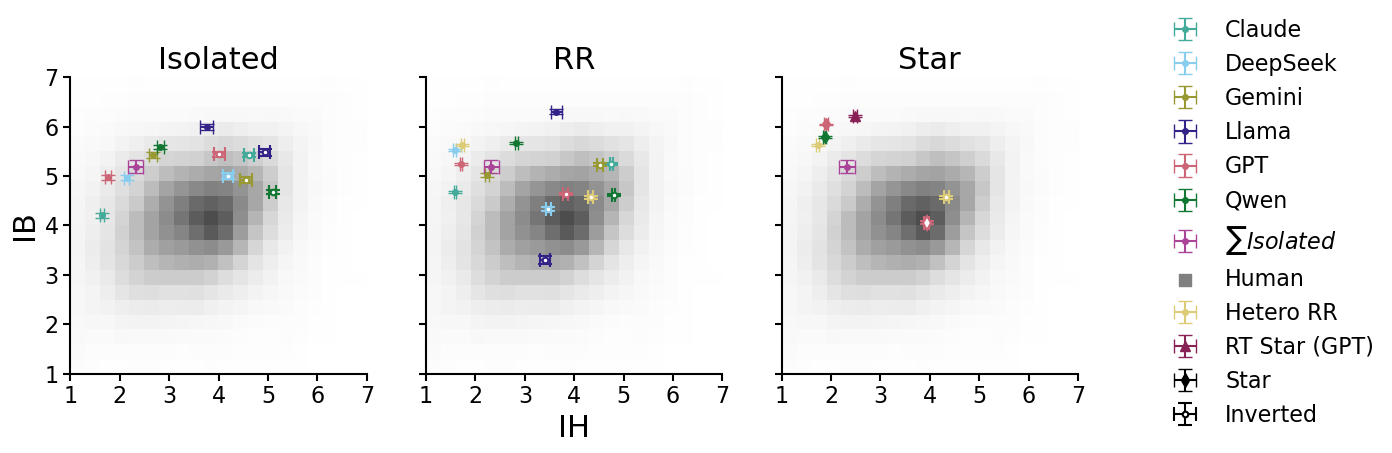

In [ ]:
text_size = 22
tick_size = 16
capsize = 5
markersize = 4
mker = 'o'

# original with legend 
fig, ax = plt.subplots(nrows=1, ncols= 3, figsize=(13, 5), sharey=True, sharex=True)
# # for just the plots (no legend)
# fig, ax = plt.subplots(nrows=1, ncols= 3, figsize=(10.25, 5), sharey=True, sharex=True)

# titles
ax[0].set_title('Isolated', fontsize=text_size)
ax[1].set_title('RR',fontsize=text_size)
ax[2].set_title('Star',fontsize=text_size)
ax[0].set_ylabel('IB',fontsize=text_size)
ax[1].set_xlabel('IH',fontsize=text_size)

# human kde
[human_kde(human_df=h2, ax=a, alpha=0.7) for a in ax]

# Ticks and spines
[a.set_xlim(1, 7) for a in ax]
[a.set_xticks([1, 2, 3, 4, 5, 6, 7]) for a in ax]
[a.set_ylim(1, 7) for a in ax]
[a.set_yticks([1, 2, 3, 4, 5, 6, 7]) for a in ax]
[a.spines['top'].set_visible(False) for a in ax]
[a.spines['right'].set_visible(False) for a in ax]
[a.tick_params(axis='both', which='major', labelsize=tick_size)  for a in ax]


####################
#### plot singles
####################
single_models = ['Claude', 'DeepSeek', 'Gemini', 'Llama', 'GPT', 'Qwen']
# For each model, get data for both categories and plot
for m in single_models:
       # Get IH data for this model (and for inverted)
       ih_data = single_plot_df[(single_plot_df['plot_label'] == m) & (single_plot_df['category'] == 'IH')]
       ih_inverted  = single_plot_df[(single_plot_df['plot_label'] == 'Inverted ' + m) & (single_plot_df['category'] == 'IH')]
       ih_mean = ih_data['mean'].values[0]
       ih_sem = ih_data['sem'].values[0]
       ih_inverted_mean = ih_inverted['mean'].values[0] 
       ih_inverted_sem = ih_inverted['sem'].values[0]

       # Get IB data for this model (and for inverted)
       ib_data = single_plot_df[(single_plot_df['plot_label'] == m) & (single_plot_df['category'] == 'IB')]
       ib_inverted  = single_plot_df[(single_plot_df['plot_label'] == 'Inverted ' + m) & (single_plot_df['category'] == 'IB')]
       ib_mean = ib_data['mean'].values[0]
       ib_sem = ib_data['sem'].values[0]
       ib_inverted_mean = ib_inverted['mean'].values[0]
       ib_inverted_sem = ib_inverted['sem'].values[0]

       # Get color from our mapping
       color = tol_muted[m]

       # Use the same marker outline color but different fill based on inverted status
       ax[0].errorbar(
              ih_mean, ib_mean,
              xerr=ih_sem, yerr=ib_sem, 
              fmt=mker, color=color, 
              markerfacecolor=color,    # Filled with color
              markeredgecolor=color,
              label=m, capsize=capsize,
              markersize=markersize
              )
       
       # Plot inverted with white fill and colored outline
       ax[0].errorbar(
              ih_inverted_mean, ib_inverted_mean,
              xerr=ih_inverted_sem, yerr=ib_inverted_sem, 
              fmt=mker, color=color, markerfacecolor='white',  # White fill
              markeredgecolor=color,    # Color outline
              markeredgewidth=1.5,      # Thicker outline
              label=None, capsize=capsize,
              markersize=markersize
              )



########################
#### plot Round Robins
########################
rr_topologies = ['Claude', 'DeepSeek', 'Gemini', 'Llama', 'GPT', 'Qwen', 'Hetero']

# For each model, get data for both categories and plot
for m in rr_topologies:
       
       # Get IH data for this model (and for inverted)
       ih_data = rr_plot_df[(rr_plot_df['plot_label'] == m) & (rr_plot_df['category'] == 'IH')]
       ih_inverted  = rr_plot_df[(rr_plot_df['plot_label'] == 'Inverted ' + m) & (rr_plot_df['category'] == 'IH')]
       ih_mean = ih_data['mean'].values[0]
       ih_sem = ih_data['sem'].values[0]
       ih_inverted_mean = ih_inverted['mean'].values[0] 
       ih_inverted_sem = ih_inverted['sem'].values[0]

       # Get IB data for this model (and for inverted)
       ib_data = rr_plot_df[(rr_plot_df['plot_label'] == m) & (rr_plot_df['category'] == 'IB')]
       ib_inverted  = rr_plot_df[(rr_plot_df['plot_label'] == 'Inverted ' + m) & (rr_plot_df['category'] == 'IB')]
       ib_mean = ib_data['mean'].values[0]
       ib_sem = ib_data['sem'].values[0]
       ib_inverted_mean = ib_inverted['mean'].values[0]
       ib_inverted_sem = ib_inverted['sem'].values[0]

       # Get color from our mapping
       color = tol_muted[m]

       # If Hetero, also plot in the third axis and label for legend
       if m == 'Hetero':
              ax[2].errorbar(
                     ih_mean, ib_mean,
                     xerr=ih_sem, yerr=ib_sem, 
                     fmt=mker, color=color, 
                     markerfacecolor=color,    # Filled with color
                     markeredgecolor=color,
                     label='Hetero RR', capsize=capsize,
                     markersize=markersize
                     )
              ax[2].errorbar(
                     ih_inverted_mean, ib_inverted_mean,
                     xerr=ih_inverted_sem, yerr=ib_inverted_sem, 
                     fmt=mker, color=color, markerfacecolor='white',  # White fill
                     markeredgecolor=color,    # Color outline
                     markeredgewidth=1.5,      # Thicker outline
                     label=None, capsize=capsize,
                     markersize=markersize
                     )
              
       # Use the same marker outline color but different fill based on inverted status
       ax[1].errorbar(
              ih_mean, ib_mean,
              xerr=ih_sem, yerr=ib_sem, 
              fmt=mker, color=color, 
              markerfacecolor=color,    # Filled with color
              markeredgecolor=color,
              label=None, capsize=capsize,
              markersize=markersize
              )
       
       # Plot inverted with white fill and colored outline
       ax[1].errorbar(
              ih_inverted_mean, ib_inverted_mean,
              xerr=ih_inverted_sem, yerr=ib_inverted_sem, 
              fmt=mker, color=color, markerfacecolor='white',  # White fill
              markeredgecolor=color,    # Color outline
              markeredgewidth=1.5,      # Thicker outline
              label=None, capsize=capsize,
              markersize=markersize
              )
       
########################
#### plot Star
########################
star_marker = 'd'
star_marker_size = 7
star_capsize = 5
star_topologies = ['RT Star (GPT)', 'GPT', 'Qwen']
star_markers = dict(zip(star_topologies, ['^', star_marker, star_marker]))  


for m in star_topologies:
       # Get IH data for this model (and for inverted)
       ih_data = star_plot_rr[(star_plot_rr['plot_label'] == m) & (star_plot_rr['category'] == 'IH')]
       ih_mean = ih_data['mean'].values[0]
       ih_sem = ih_data['sem'].values[0]

       # Get IB data for this model (and for inverted)
       ib_data = star_plot_rr[(star_plot_rr['plot_label'] == m) & (star_plot_rr['category'] == 'IB')]
       ib_mean = ib_data['mean'].values[0]
       ib_sem = ib_data['sem'].values[0]


       marker_style = star_markers[m]
       if m == 'RT Star (GPT)':
              color = tol_muted['RT Star']
              # Use the same marker outline color but different fill based on inverted status
              ax[2].errorbar(
                     ih_mean, ib_mean,
                     xerr=ih_sem, yerr=ib_sem, 
                     fmt=marker_style, color=color, 
                     markerfacecolor=color,    # Filled with color
                     markeredgecolor=color,
                     label=m, capsize=star_capsize,
                     markersize=star_marker_size
                     )
       else: 
              color = tol_muted[m]
              if m == 'GPT': 
                     # plot inverted
                     # Get IH data for this model (and for inverted)
                     ih_inverted  = star_plot_rr[(star_plot_rr['plot_label'] == 'Inverted ' + m) & (rr_plot_df['category'] == 'IH')]
                     ih_inverted_mean = ih_inverted['mean'].values[0]
                     ih_inverted_sem = ih_inverted['sem'].values[0]

                     # Get IB data for this model (and for inverted)
                     ib_inverted  = star_plot_rr[(star_plot_rr['plot_label'] == 'Inverted ' + m) & (rr_plot_df['category'] == 'IB')]
                     ib_inverted_mean = ib_inverted['mean'].values[0]
                     ib_inverted_sem = ib_inverted['sem'].values[0]

                     # Plot inverted with white fill and colored outline
                     ax[2].errorbar(
                            ih_inverted_mean, ib_inverted_mean,
                            xerr=ih_inverted_sem, yerr=ib_inverted_sem, 
                            fmt=marker_style, color=color, markerfacecolor='white',  # White fill
                            markeredgecolor=color,    # Color outline
                            markeredgewidth=1.5,      # Thicker outline
                            label=None, capsize=star_capsize,
                            markersize=star_marker_size
                            )

              # Use the same marker outline color but different fill based on inverted status
              ax[2].errorbar(
                     ih_mean, ib_mean,
                     xerr=ih_sem, yerr=ib_sem, 
                     fmt=marker_style, color=color, 
                     markerfacecolor=color,    # Filled with color
                     markeredgecolor=color,
                     label=None, capsize=capsize,
                     markersize=1.5*markersize
                     )

####################
#### plot extras
####################
# General star MARKER for legend
ax[2].errorbar(
              8, 8,
              xerr=1e3, yerr=1e3, 
              fmt=star_marker, color='black', 
              markerfacecolor='black',    # Filled with color
              markeredgecolor='black',
              label='Star', capsize=star_capsize,
              markersize=star_marker_size
              )

# Linear combination of singles (LinCombo) 
y_ib = 5.192746    
y_ib_error = 0.130093
x_ih = 2.323340    
x_ih_error = 0.154879
LC_color = tol_muted['pink']

ax[0].errorbar(
       x_ih, y_ib,
       xerr=x_ih_error, yerr=y_ib_error, 
       fmt=mker, color=LC_color, markerfacecolor=LC_color,  # White fill
       markeredgecolor=LC_color,    # Color outline
       label=r'$\sum{Isolated}$', capsize=capsize,
       markersize=markersize
       )
ax[1].errorbar(
       x_ih, y_ib,
       xerr=x_ih_error, yerr=y_ib_error, 
       fmt=mker, color=LC_color, markerfacecolor=LC_color,  # White fill
       markeredgecolor=LC_color,    # Color outline
       label=None, capsize=capsize,
       markersize=markersize
       )
ax[2].errorbar(
       x_ih, y_ib,
       xerr=x_ih_error, yerr=y_ib_error, 
       fmt=mker, color=LC_color, markerfacecolor=LC_color,  # White fill
       markeredgecolor=LC_color,    # Color outline
       label=None, capsize=capsize,
       markersize=markersize
       )

# Add generic outside axis limits for legend
# Inverted
ax[2].errorbar(
       8, 8,
       xerr=1e3, yerr=1e3, 
       fmt=mker, color= 'black', markerfacecolor='white',  # White fill
       markeredgecolor= 'black',    # Color outline
       markeredgewidth=1.5,      # Thicker outline
       label='Inverted', capsize=capsize,
       markersize=markersize
       )

# LEGEND
fig.legend(loc= 'center left',  #'upper center',        # Align by upper center
                bbox_to_anchor= (.95, 0.5), #(0.5, -0.16), # Position below axes (x=center, y=below)
                frameon=False, 
                fontsize=tick_size)
                
              
ax[0].set_aspect(1, share=True) # equal aspect ratio for all subplots


fig.savefig('figures/poster_IHvIB.svg', bbox_inches='tight')

# LaaJ - Methods (off-topic) and Results (all rationale)

## load all classification data

In [15]:
topologies = {
    "Single-Agent": os.path.join(BASE_DIR, "results"),
    "Multi-Agent": os.path.join(BASE_DIR, "results_multi"),
    "Star-Topology": os.path.join(BASE_DIR, "results_multi_star")
}

all_classification_data = []
for topo_name, dir_path in topologies.items():
    if os.path.exists(dir_path):
        for fpath in glob.glob(os.path.join(dir_path, "*_classification.jsonl")):
            try:
                dfj = pd.read_json(fpath, lines=True)
                if "selected_categories" in dfj.columns:
                    dfj['topology'] = topo_name
                    # Add dataset column with the filename (without path and extension)
                    dataset_name = os.path.basename(fpath).replace('_classification.jsonl', '')
                    dfj['dataset'] = dataset_name
                    all_classification_data.append(dfj)
            except Exception as e:
                print(f"Error loading {fpath}: {e}")

## combined_df and exploded df

In [16]:
# =============================================================================
# FROM RAM'S HEATMAPS FOR AGENT-SPECIFIC ANALYSIS (WITH ABSOLUTE FREQUENCIES)
# =============================================================================

# Standardize columns across all classification dataframes before concatenation
for i, df in enumerate(all_classification_data):
    # Add message_index if missing, default to 0
    if 'message_index' not in df.columns:
        df['message_index'] = 0
    
    # Map extracted_answer to answer if needed
    if 'extracted_answer' in df.columns and 'answer' not in df.columns:
        df['answer'] = df['extracted_answer']
    elif 'extracted_answer' in df.columns and 'answer' in df.columns:
        # If both exist, prioritize extracted_answer
        df['answer'] = df['extracted_answer']
    
    # Map extracted_confidence to confidence if needed
    if 'extracted_confidence' in df.columns and 'confidence' not in df.columns:
        df['confidence'] = df['extracted_confidence']
    elif 'extracted_confidence' in df.columns and 'confidence' in df.columns:
        # If both exist, prioritize extracted_confidence
        df['confidence'] = df['extracted_confidence']
    
    # Map agent_model to model_name if needed
    if 'agent_model' in df.columns and 'model_name' not in df.columns:
        df['model_name'] = df['agent_model']
    elif 'agent_model' in df.columns and 'model_name' in df.columns:
        # If both exist, prioritize agent_model
        df['model_name'] = df['agent_model']

print(f"Standardized {len(all_classification_data)} classification dataframes")

# Combine all classification data
combined_df = pd.concat(all_classification_data, ignore_index=True)

# Create exploded dataframe for accurate category counting (now happens later)
# exploded_df = combined_df.explode("selected_categories")
# exploded_df = exploded_df[exploded_df['selected_categories'].notna()]

# Add question classification columns based on question_id ranges
def classify_question(question_id):
    if 1 <= question_id  <= 40:
        return False, 'IH'
    elif 41 <= question_id <= 90:
        return False, 'IB'
    elif 101 <= question_id <= 140:
        return True, 'IH'
    elif 141 <= question_id <= 190:
        return True, 'IB'
    else:
        return None, None

# Apply classification to both dataframes
classification_results = combined_df['question_id'].apply(classify_question)
combined_df['question_inverted'] = [result[0] for result in classification_results]
combined_df['question_category'] = [result[1] for result in classification_results]

# exploded_classification_results = exploded_df['question_id'].apply(classify_question)
# exploded_df['question_inverted'] = [result[0] for result in exploded_classification_results]
# exploded_df['question_category'] = [result[1] for result in exploded_classification_results]

# Add group classification columns based on dataset naming patterns
def classify_group(dataset_name):
    """
    Classify group characteristics from dataset name.
    Returns: (group_inverted, group_type, group_model, group_evil)
    """
    dataset = str(dataset_name).lower()
    
    # Determine if inverted
    group_inverted = 'inverted' in dataset
    
    # Determine if evil
    group_evil = 'evil' in dataset
    
    # Determine group type
    if dataset.startswith('single_'):
        group_type = 'isolated'
    elif '_ring_' in dataset:
        group_type = 'ring'
    elif '_star_' in dataset:
        group_type = 'star'
    else:
        group_type = 'unknown'
    
    # Extract model name
    group_model = 'unknown'
    
    # Model extraction patterns
    if 'openai' in dataset or 'gpt' in dataset:
        group_model = 'GPT'
    elif 'anthropic' in dataset or 'claude' in dataset:
        group_model = 'claude'
    elif 'google' in dataset or 'gemini' in dataset:
        group_model = 'gemini'
    elif 'meta-llama' in dataset or 'llama' in dataset:
        group_model = 'llama'
    elif 'qwen' in dataset:
        group_model = 'qwen'
    elif 'deepseek' in dataset:
        group_model = 'deepseek'
    elif 'mistral' in dataset:
        group_model = 'mistral'
    elif 'hetero' in dataset:
        group_model = 'mixed'
    
    return group_inverted, group_type, group_model, group_evil

# Apply group classification to both dataframes
group_results = combined_df['dataset'].apply(classify_group)
combined_df['group_inverted'] = [result[0] for result in group_results]
combined_df['group_type'] = [result[1] for result in group_results]
combined_df['group_model'] = [result[2] for result in group_results]
combined_df['group_evil'] = [result[3] for result in group_results]

# exploded_group_results = exploded_df['dataset'].apply(classify_group)
# exploded_df['group_inverted'] = [result[0] for result in exploded_group_results]
# exploded_df['group_type'] = [result[1] for result in exploded_group_results]
# exploded_df['group_model'] = [result[2] for result in exploded_group_results]
# exploded_df['group_evil'] = [result[3] for result in exploded_group_results]

# Create exploded dataframe for accurate category counting 
exploded_df = combined_df.explode("selected_categories")
exploded_df0 = exploded_df.copy()
exploded_df = exploded_df[exploded_df['selected_categories'].notna()]

print(f"Added question classification columns:")
print(f"Question inverted distribution: {combined_df['question_inverted'].value_counts()}")
print(f"Question category distribution: {combined_df['question_category'].value_counts()}")

print(f"\nAdded group classification columns:")
print(f"Group inverted distribution: {combined_df['group_inverted'].value_counts()}")
print(f"Group type distribution: {combined_df['group_type'].value_counts()}")
print(f"Group model distribution: {combined_df['group_model'].value_counts()}")
print(f"Group evil distribution: {combined_df['group_evil'].value_counts()}")

print(f"\nExploded dataframe created with {len(exploded_df)} category instances from {len(combined_df)} responses")

Standardized 30 classification dataframes
Added question classification columns:
Question inverted distribution: question_inverted
False    256843
True     213797
Name: count, dtype: int64
Question category distribution: question_category
IB    262191
IH    208449
Name: count, dtype: int64

Added group classification columns:
Group inverted distribution: group_inverted
False    256843
True     213797
Name: count, dtype: int64
Group type distribution: group_type
ring        362755
star         94925
isolated     12960
Name: count, dtype: int64
Group model distribution: group_model
GPT         122946
qwen         79726
deepseek     54107
gemini       54011
claude       54008
llama        53992
mixed        51850
Name: count, dtype: int64
Group evil distribution: group_evil
False    453371
True      17269
Name: count, dtype: int64

Exploded dataframe created with 927376 category instances from 470640 responses


## map classification of off-topic-reaosns to off-topic-categories

In [17]:
# Load the classifications mapping
classifications_file = os.path.join(BASE_DIR, "classifications.json")
with open(classifications_file, 'r') as f:
    classifications_mapping = json.load(f)

# First, get the value counts to determine the mapping
off_topic_raw_counts = combined_df['off_topic_reason'].value_counts()

# Create a mapping from off_topic_reason values to classification categories
def map_off_topic_to_category(off_topic_reason):
    """Map off_topic_reason to standardized categories using the classifications.json"""
    if pd.isna(off_topic_reason) or off_topic_reason == '':
        return None
    
    # Try to find the reason in our classifications mapping using value_counts index + 1
    reason_str = str(off_topic_reason).strip()
    
    # Find the index of this reason in the value_counts and add 1
    try:
        reason_index = list(off_topic_raw_counts.index).index(reason_str) + 1
        classification_key = str(reason_index)
        return classifications_mapping.get(classification_key, f"Unknown Classification ({classification_key})")
    except ValueError:
        # If reason not found in value_counts, try direct lookup as before
        if reason_str.isdigit():
            return classifications_mapping.get(reason_str, "Unknown Classification")
        
        # If it's already a text description, try to find the best match
        for key, category in classifications_mapping.items():
            if reason_str.lower() == category.lower():
                return category
        
        # If no exact match, return the original reason
        return reason_str

# Apply the mapping to create standardized categories
combined_df['off_topic_category'] = combined_df['off_topic_reason'].apply(map_off_topic_to_category)

## aggregate  off-topic categories for plotting (plot_offtopic_label)
Note: Other is used for misinterpretation or topic shfiting reframing


In [18]:
off_topic_mappings = {'Off-Topic/Meta-Discussion': 'Meta-Discussion',
                      'Off-Topic/New Topic': 'New Topic',
                      'Empty/Irrelevant Response': 'Empty/Irrelevant',
                      'Refusal to Answer': 'Refusal',
                      'Refusal to Answer (Safety Guidelines)': 'Refusal',
                      'No Rationale Provided': 'No Rationale',
                      'Off-Topic/Topic Shift (Reframing)': 'Other',
                      'Misinterpretation of Question/Scenario' :'Other'
                      }
# Note: Other is used for misinterpretation or topic shfiting reframing
combined_df['plot_offtopic_label'] = combined_df['off_topic_category'].apply(
    lambda x: off_topic_mappings.get(x, x) if (pd.notna(x) or x != 'None') else 'What is this?'
)

In [19]:
#total counts
combined_df['plot_offtopic_label'].value_counts()

plot_offtopic_label
Empty/Irrelevant    17181
Meta-Discussion     14478
New Topic            3595
Refusal              2060
No Rationale         1678
Other                  87
Name: count, dtype: int64

In [20]:
combined_df['group_model'].unique()

array(['GPT', 'gemini', 'deepseek', 'claude', 'llama', 'qwen', 'mixed'],
      dtype=object)

## Calculate off-topic heatmap

### function counts_to_df (doesn't use exploded) and dataframe


In [21]:
# function to convert counts to dataframe with percentages
def counts_to_df(count_series, group_label, group_size):
    """Convert a Series of counts to a DataFrame with percentages."""
    df = pd.DataFrame(count_series, columns=['group', 'count']).reset_index()
    df['group'] = group_label
    df['percentage'] = (df['count'] / group_size) * 100
    return df

In [22]:
# test the function with the off_topic_category counts
test = counts_to_df(combined_df['plot_offtopic_label'].value_counts(),group_label = 'Total', group_size=len(combined_df))
test

,plot_offtopic_label,group,count,percentage
0,Empty/Irrelevant,Total,17181,3.650561
1,Meta-Discussion,Total,14478,3.076237
2,New Topic,Total,3595,0.763853
3,Refusal,Total,2060,0.437702
4,No Rationale,Total,1678,0.356536
5,Other,Total,87,0.018485


### topology groupings for QC

In [23]:
# excluded dfs
excluded_combined_df = combined_df[combined_df['is_response_off_topic'] == True]
n_combined = len(combined_df)

# single excluded 
ex_single_comb = excluded_combined_df[excluded_combined_df['group_type'] == 'isolated']
n_single_comb = len(combined_df[combined_df['group_type'] == 'isolated'])

# rr all excluded 
ex_rr_comb = excluded_combined_df[excluded_combined_df['group_type'] == 'ring']
n_rr_comb = len(combined_df[combined_df['group_type'] == 'ring'])

# star (non-evil) excluded 
ex_star_comb = excluded_combined_df[(excluded_combined_df['group_type'] == 'star') & (excluded_combined_df['group_evil'] == False)]
n_star_comb = len(combined_df[(combined_df['group_type'] == 'star') & (combined_df['group_evil'] == False)])
# star (evil) excluded
ex_evil_star_comb = excluded_combined_df[(excluded_combined_df['group_type'] == 'star') & (excluded_combined_df['group_evil'] == True)]
n_evil_star_comb = len(combined_df[(combined_df['group_type'] == 'star') & (combined_df['group_evil'] == True)])

# individual counts for rr by model and type
# rr llama excluded 
ex_rr_llama_comb = excluded_combined_df[(excluded_combined_df['group_type'] == 'ring') & (excluded_combined_df['group_model'] == 'llama')]
n_rr_llama_comb = len(combined_df[(combined_df['group_type'] == 'ring') & (combined_df['group_model'] == 'llama')])

# rr hetero excluded 
ex_rr_het_comb = excluded_combined_df[(excluded_combined_df['group_type'] == 'ring') & (excluded_combined_df['group_model'] == 'mixed')]
n_rr_het_comb = len(combined_df[(combined_df['group_type'] == 'ring') & (combined_df['group_model'] == 'mixed')])


# List of dataframes for overview heatman
group_label_list = ['Total', 'Isolated', 'RR', 'Star', 'RT Star']
group_size_list = [n_combined, n_single_comb, n_rr_comb, n_star_comb, n_evil_star_comb]
group_df_list = [combined_df, ex_single_comb, ex_rr_comb, ex_star_comb, ex_evil_star_comb]

# list of dataframes for round robin only heatmap
rr_group_label_list =[]
rr_group_size_list = [] # [n_rr_comb]
rr_group_df_list = [] # [ex_rr_comb]

for model in combined_df['group_model'].unique():
   this_df = excluded_combined_df[(excluded_combined_df['group_type'] == 'ring') & (excluded_combined_df['group_model'] == model)].copy()
   this_n = len(combined_df[(combined_df['group_type'] == 'ring') & (combined_df['group_model'] == model)])
   rr_group_df_list.append(this_df)
   rr_group_size_list.append(this_n)
   if model == 'mixed':
     rr_group_label_list.append('Hetero')
   elif model == 'GPT':
      rr_group_label_list.append(model)
   else:
      rr_group_label_list.append(model.capitalize())
   del this_df
   del this_n
    

In [24]:
# heatmap for overview of all off-topic responses
off_topic_heatmap_df = pd.DataFrame()
for i in range(len(group_label_list)):
    group_label = group_label_list[i]
    group_size = group_size_list[i]
    group_df = group_df_list[i]
    
    # Convert counts to DataFrame
    df = counts_to_df(group_df['plot_offtopic_label'].value_counts(), group_label, group_size)
    
    # Append to the main DataFrame
    off_topic_heatmap_df = pd.concat([off_topic_heatmap_df, df], ignore_index=True)

# pivot the dataframe for heatmap - also need to reindex for presentation
off_topic_heatmap_df['group'] = off_topic_heatmap_df['group'].apply(lambda x: 'RT STAR\n(GPT)' if x=='RT Star' else x)
pivoted = off_topic_heatmap_df.pivot(index="plot_offtopic_label", columns="group", values="percentage")
pivoted = pivoted.reindex(columns=['Total','Isolated', 'RR', 'Star', 'RT STAR\n(GPT)'])
pivoted = pivoted.reindex(index=['Empty/Irrelevant','Meta-Discussion', 'New Topic',  'Refusal', 'No Rationale', 'Other'])


In [25]:
pivoted

group,Total,Isolated,RR,Star,RT STAR\n(GPT)
plot_offtopic_label,,,,,
Empty/Irrelevant,3.650561,0.084877,4.697937,0.127485,0.167931
Meta-Discussion,3.076237,NaN,3.877824,0.518955,0.046326
New Topic,0.763853,0.015432,0.978071,0.045071,0.057907
Refusal,0.437702,2.168210,0.459263,0.124910,0.092652
No Rationale,0.356536,NaN,0.439691,0.095292,0.052117
Other,0.018485,NaN,0.019848,0.019316,NaN


In [26]:
# heatmap for round roubin specifically
off_topic_heatmap_rr_df = pd.DataFrame()
for i in range(len(rr_group_label_list)):
    group_label = rr_group_label_list[i]
    group_size = rr_group_size_list[i]
    group_df = rr_group_df_list[i]
    
    # Convert counts to DataFrame
    df = counts_to_df(group_df['plot_offtopic_label'].value_counts(), group_label, group_size)
    
    # Append to the main DataFrame
    off_topic_heatmap_rr_df = pd.concat([off_topic_heatmap_rr_df, df], ignore_index=True)

# pivot the dataframe for heatmap
pivoted_rr = off_topic_heatmap_rr_df.pivot(index="plot_offtopic_label", columns="group", values="percentage")
pivoted_rr = pivoted_rr.reindex(columns=['Hetero', 'GPT', 'Llama', 'Claude', 'Gemini', 'Qwen', 'Deepseek'])
pivoted_rr = pivoted_rr.reindex(index=['Empty/Irrelevant','Meta-Discussion', 'New Topic',  'Refusal', 'No Rationale', 'Other'])



In [27]:
#pivoted_rr = off_topic_heatmap_rr_df.pivot(index="plot_offtopic_label", columns="group", values="percentage")
#pivoted_rr

## heatmap (off-topic)

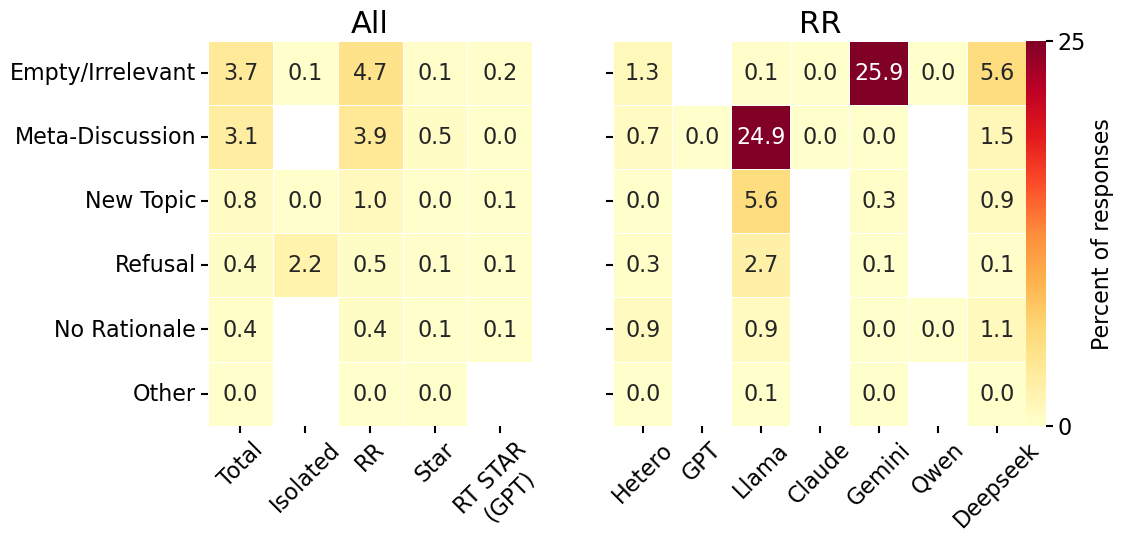

In [28]:
off_topic_plot = pivoted


# Draw a heatmap with the numeric values in each cell
fig, axs = plt.subplots(ncols = 2, figsize=(11.5, 5), sharey=True, gridspec_kw={'width_ratios': [2, 3]})

# subptitle without colorbar
# plt.suptitle('Off-topic response (%)', fontsize=text_size)

ax = axs[0]
hm = sns.heatmap(off_topic_plot, annot=True, fmt=".1f", linewidths=.5, ax=ax, 
                 cmap='YlOrRd',annot_kws={"size": tick_size},cbar = False,vmin=0, vmax=25)
                 #cbar_kws = {'orientation':'horizontal', 'location':'bottom', 'pad':.25, 'fraction': .3})
hm.tick_params(labelsize=tick_size)
hm.set_xticklabels(hm.get_xticklabels(), rotation=45)

ax.set_title('All', fontsize=text_size) 
ax.set_xlabel('')
ax.set_ylabel('')

ax1 = axs[1]
# # without colorbar
# hm = sns.heatmap(pivoted_rr, annot=True, fmt=".1f", linewidths=.5, ax=ax1, 
#                  cmap='YlOrRd',annot_kws={"size": tick_size},cbar = False, vmin=0, vmax=25)

# with colorbar
hm = sns.heatmap(pivoted_rr, annot=True, fmt=".1f", linewidths=.5, ax=ax1, 
                 cmap='YlOrRd',annot_kws={"size": tick_size},cbar = True, vmin=0, vmax=25,
                 cbar_kws={'location': 'right', 'orientation': 'vertical', 'pad':0, 'label':'Percent of responses', 'ticks':[0,25]})

# colorbar label
hm.figure.axes[-1].yaxis.label.set_size(tick_size)
# colorbar ticks
cbar = hm.collections[0].colorbar
cbar.ax.tick_params(labelsize=tick_size)

hm.tick_params(labelsize=tick_size)
hm.set_xticklabels(hm.get_xticklabels(), rotation=45)
ax1.set_title('RR', fontsize=text_size) 
ax1.set_xlabel('')
ax1.set_ylabel('')


fig.savefig('figures/poster_off-topic.svg', bbox_inches='tight')

# Stat tests

## round 1

In [29]:
# import pandas as pd
# import numpy as np
# from scipy.stats import mannwhitneyu, norm
# from IPython.display import display, HTML

# results = []

# # Extract unique labels from single_by_category for matching
# available_labels = single_by_category['label'].unique()

# # Loop over agent_shortnames in rr_by_agent_df
# for agent in rr_by_agent_df['agent_shortname'].unique():
#     if 'inverted' in agent:
#         # e.g. "claude_inverted" -> "GGB_inverted_claude"
#         base = agent.replace('_inverted', '')
#         label = f'GGB_inverted_{base}'
#     else:
#         label = f'GGB_{agent}'

#     if label not in available_labels:
#         continue

#     y = rr_by_agent_df[(rr_by_agent_df['agent_shortname'] == agent) &
#                        (rr_by_agent_df['round'] == 1) &
#                         (rr_by_agent_df['message_index'] == 1)
#       ]['agent_answer'].dropna()
#     x = single_df[single_df['label'] == label]['answer_numeric'].dropna()

#     if len(x) < 2 or len(y) < 2:
#         continue

#     stat, p = mannwhitneyu(x, y, alternative='two-sided')

#     try:
#         z = norm.ppf(1 - p / 2)
#         r = z / np.sqrt(len(x) + len(y))
#     except:
#         r = np.nan

#     results.append({
#         'agent': agent,
#         'label': label,
#         'n_iso': len(x),
#         'n_rr': len(y),
#         'p_value': p,
#         'r': r
#     })

# results_df = pd.DataFrame(results)

# # Round selected float columns
# results_df['p_value'] = results_df['p_value'].round(2)
# results_df['effect_size_r'] = results_df['effect_size_r'].round(2)


# # for better display/sorting:
# # Create a helper column with base agent name (without "_inverted")
# results_df['agent_base'] = results_df['agent'].str.replace('_inverted', '', regex=False)

# # Optional: set a consistent order based on unique agent bases
# agent_order = results_df['agent_base'].drop_duplicates().tolist()

# # Sort by agent base first, then put normal agent before inverted
# results_df = results_df.sort_values(
#     by=['agent_base', 'agent'],
#     key=lambda col: col if col.name != 'agent' else col.apply(lambda x: (x.endswith('_inverted'), x))
# ).reset_index(drop=True)

# # Drop the helper column if not needed
# results_df = results_df.drop(columns='agent_base')

# #print(results_df)
# results_df






## round 4

### for poster

In [30]:
import pandas as pd
import numpy as np
from scipy.stats import mannwhitneyu, norm
from IPython.display import display, HTML

results = []

# Extract unique labels from single_by_category for matching
available_labels = single_by_category['label'].unique()

# Loop over agent_shortnames in rr_by_agent_df
for agent in rr_by_agent_df['agent_shortname'].unique():
    if 'inverted' in agent:
        # e.g. "claude_inverted" -> "GGB_inverted_claude"
        base = agent.replace('_inverted', '')
        label = f'GGB_inverted_{base}'
    else:
        label = f'GGB_{agent}'

    if label not in available_labels:
        continue

    y = rr_by_agent_df[
        (rr_by_agent_df['agent_shortname'] == agent) &
        (rr_by_agent_df['round'] == 4) &
        (~rr_by_agent_df['chat_type'].isin(['ggb_hetero_ring', 'ggb_inverted_hetero_ring']))
    ]['agent_answer'].dropna()
    x = single_df[single_df['label'] == label]['answer_numeric'].dropna()

    if len(x) < 2 or len(y) < 2:
        continue

    n1 = len(x)
    n2 = len(y)
    stat, p = mannwhitneyu(x, y, alternative='two-sided')

    try:
        #z = norm.ppf(1 - p / 2)
        #r = z / np.sqrt(len(x) + len(y))
        # instead Manual z-score calculation for p~0
        mean_u = n1 * n2 / 2
        std_u = np.sqrt(n1 * n2 * (n1 + n2 + 1) / 12)
        z = (stat - mean_u) / std_u

        # Effect size r
        r = abs(z) / np.sqrt(n1 + n2)
    except:
        r = np.nan

    results.append({
        'agent': agent,
        'n_iso': len(x),
        'n_rr': len(y),
        'p': p,
        'r': r
    })

results_df = pd.DataFrame(results)

# # Round selected float columns
# results_df['p_value'] = results_df['p_value']
# results_df['effect_size'] = results_df['effect_size']


# for better display/sorting:
# Create a helper column with base agent name (without "_inverted")
results_df['agent_base'] = results_df['agent'].str.replace('_inverted', '', regex=False)

# Optional: set a consistent order based on unique agent bases
agent_order = results_df['agent_base'].drop_duplicates().tolist()

# Sort by agent base first, then put normal agent before inverted
results_df = results_df.sort_values(
    by=['agent_base', 'agent'],
    key=lambda col: col if col.name != 'agent' else col.apply(lambda x: (x.endswith('_inverted'), x))
).reset_index(drop=True)

# Drop the helper column if not needed
results_df = results_df.drop(columns='agent_base')

results_df['agent'] = results_df['agent'].apply(lambda x: x.capitalize() )

results_df['p'] = results_df['p'].apply(lambda x: f"{x:.1e}")
results_df['r'] = results_df['r'].apply(lambda x: f"{x:.1e}")


#print(results_df)
results_df


,agent,n_iso,n_rr,p,r
0,Claude,1080,6479,6.4e-04,3.9e-02
1,Claude_inverted,1080,6474,9.6e-01,4.9e-04
2,Deepseek,1069,5295,9.0e-01,1.6e-03
3,Deepseek_inverted,1069,5599,5.4e-14,9.1e-02
4,Gemini,1080,4165,4.0e-18,1.2e-01
5,Gemini_inverted,1080,5331,5.5e-02,2.3e-02
6,Gpt,1080,6480,7.2e-02,2.0e-02
7,Gpt_inverted,1080,6478,5.7e-13,8.2e-02
8,Llama,852,1259,5.5e-01,1.2e-02
9,Llama_inverted,943,1551,1.3e-76,3.6e-01


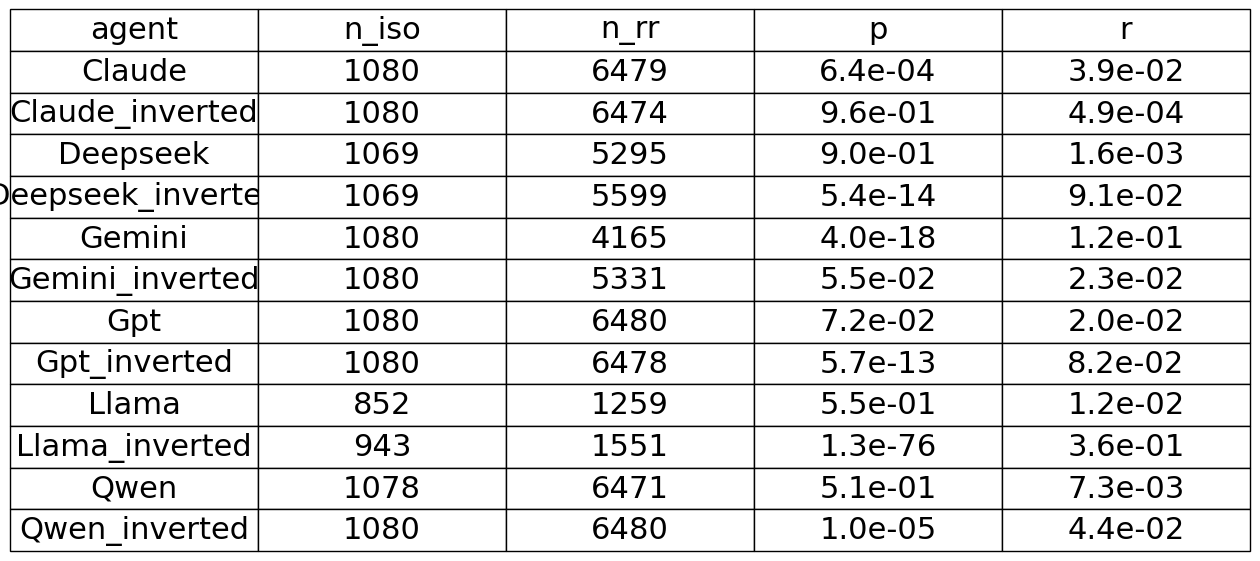

In [31]:
df = results_df
# Create a figure and axis
fig, ax = plt.subplots()

# Hide the axes
ax.axis("off")

# Create the table
table = plt.table(cellText=df.values, colLabels=df.columns, loc='center',  cellLoc='center')
table.auto_set_font_size(False)
table.set_fontsize(text_size)
table.scale(2.5,2.5)
# Display the table
plt.show()

fig.savefig('figures/table.svg', bbox_inches='tight')

In [32]:
import pandas as pd
import numpy as np
from scipy.stats import mannwhitneyu, norm
from IPython.display import display, HTML

results = []

# Extract unique labels from single_by_category for matching
available_labels = single_by_category['label'].unique()

# Define categories
categories = single_df['category'].unique()

for cat in categories:
    for ggb_type in ['GGB', 'GGB_inverted']:
        if ggb_type == 'GGB':
            question_type = 'Original'
        else:
            question_type = 'Inverted'
        # Aggregate single answers (x) across all agents for this category and ggb_type
        x = single_df[
            (single_df['category'] == cat) &
            (single_df['label'].str.startswith(ggb_type))
        ]['answer_numeric'].dropna()

        if len(x) < 2:
            continue  # Skip if not enough data for singles

        # For ring answers (y), aggregate across all chat_types matching ggb_type and category
        if ggb_type == 'GGB':
            chat_types = ['ggb_hetero_ring']
        else:
            chat_types = ['ggb_inverted_hetero_ring']

        y = rr_by_agent_df[
            (rr_by_agent_df['round'] == 4) &
            (rr_by_agent_df['chat_type'].isin(chat_types)) &
            (rr_by_agent_df['category'] == cat)
        ]['agent_answer'].dropna()

        if len(y) < 2:
            continue  # Skip if not enough data for ring

        n1 = len(x)
        n2 = len(y)
        stat, p = mannwhitneyu(x, y, alternative='two-sided')

        try:
            mean_u = n1 * n2 / 2
            std_u = np.sqrt(n1 * n2 * (n1 + n2 + 1) / 12)
            z = (stat - mean_u) / std_u
            r = abs(z) / np.sqrt(n1 + n2)
        except:
            r = np.nan

        results.append({
            'category': cat,
            'question': question_type,
            'n_iso': n1,
            'n_rr': n2,
            'p': p,
            'r': r
        })

results_df = pd.DataFrame(results)

# # Round selected float columns
# results_df['p_value'] = results_df['p_value'].round(2)
# results_df['effect_size_r'] = results_df['effect_size_r'].round(2)

results_df['p'] = results_df['p'].apply(lambda x: f"{x:.1e}")
results_df['r'] = results_df['r'].apply(lambda x: f"{x:.1e}")

# Sort results by category and ggb_type
results_df = results_df.sort_values(by=['category', 'question']).reset_index(drop=True)

#print(results_df)
results_df


,category,question,n_iso,n_rr,p,r
0,IB,Inverted,3573,3383,9.9e-19,1.0e-01
1,IB,Original,7160,3363,2.2e-54,1.5e-01
2,IH,Inverted,2759,2706,7.1e-01,4.8e-03
3,IH,Original,5411,2644,0.0e+00,4.2e-01


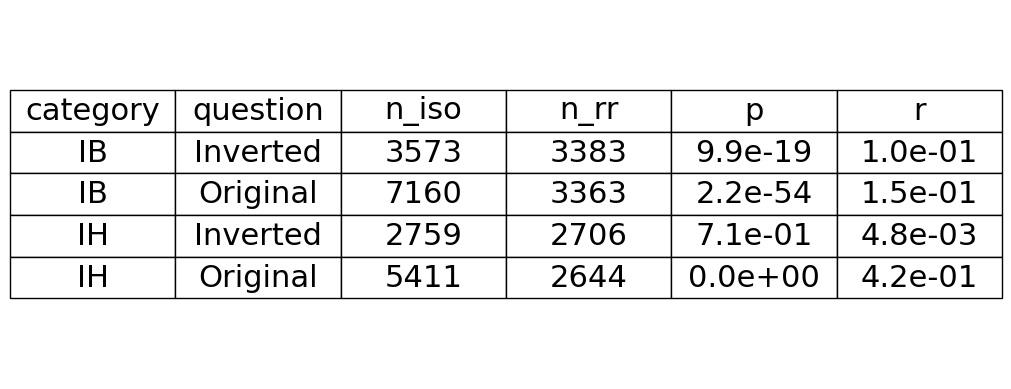

In [33]:
df = results_df
# Create a figure and axis
fig, ax = plt.subplots()

# Hide the axes
ax.axis("off")

# Create the table
table = plt.table(cellText=df.values, colLabels=df.columns, loc='center',  cellLoc='center')
table.auto_set_font_size(False)
table.set_fontsize(text_size)
table.scale(2,2.5)
# Display the table
plt.show()

fig.savefig('figures/table.svg', bbox_inches='tight')

In [34]:
import plotly.graph_objects as go

# Create a table
fig = go.Figure(data=[go.Table(
    header=dict(values=list(df.columns),
                fill_color='paleturquoise',
                align='center'),
    cells=dict(values=[df.category, df.question, df.n_iso, df.n_rr, df.p, df.r],
               fill_color='lavender',
               align='center',
               height=30, 
        font=dict(size=text_size, family='Arial')  # Cell font size and family
    )
)])

# Update layout for figure size, margin, and font
fig.update_layout(
    width=800,     # figure width in pixels
    height=500,    # figure height in pixels
    font=dict(size=text_size)  # General font size
)

# Show the figure


### for HCISS post-review revision : Mann Whitney (single v rign per agent)

In [35]:
# Mann-Whitney U Test between singles and ring responses per agent (final round, excluding hetero ring chats)
import pandas as pd
import numpy as np
from scipy.stats import mannwhitneyu, norm
from IPython.display import display, HTML

results = []

# Extract unique labels from single_by_category for matching
available_labels = single_by_category['label'].unique()

# Loop over agent_shortnames in rr_by_agent_df
for agent in rr_by_agent_df['agent_shortname'].unique():
    if 'inverted' in agent:
        # e.g. "claude_inverted" -> "GGB_inverted_claude"
        base = agent.replace('_inverted', '')
        label = f'GGB_inverted_{base}'
    else:
        label = f'GGB_{agent}'

    if label not in available_labels:
        continue

    y = rr_by_agent_df[
        (rr_by_agent_df['agent_shortname'] == agent) &
        (rr_by_agent_df['round'] == 4) &
        (~rr_by_agent_df['chat_type'].isin(['ggb_hetero_ring', 'ggb_inverted_hetero_ring']))
    ]['agent_answer'].dropna()
    x = single_df[single_df['label'] == label]['answer_numeric'].dropna()

    if len(x) < 2 or len(y) < 2:
        continue

    n1 = len(x)
    n2 = len(y)
    stat, p = mannwhitneyu(x, y, alternative='two-sided')

    try:
        #z = norm.ppf(1 - p / 2)
        #r = z / np.sqrt(len(x) + len(y))
        # instead Manual z-score calculation for p~0
        mean_u = n1 * n2 / 2
        std_u = np.sqrt(n1 * n2 * (n1 + n2 + 1) / 12)
        z = (stat - mean_u) / std_u

        # Effect size r
        r = abs(z) / np.sqrt(n1 + n2)
    except:
        r = np.nan

    results.append({
        'agent': agent,
        'label': label,
        'n_x': len(x),
        'n_y': len(y),
        'U': stat,
        'p_value': p,
        'effect_size_r': r
    })

results_df = pd.DataFrame(results)

# Round selected float columns (don't round p-values to avoid 0.00)
# results_df['p_value'] = results_df['p_value'].round(2)
# results_df['effect_size_r'] = results_df['effect_size_r'].round(2)


# for better display/sorting:
# Create a helper column with base agent name (without "_inverted")
results_df['agent_base'] = results_df['agent'].str.replace('_inverted', '', regex=False)

# Optional: set a consistent order based on unique agent bases
agent_order = results_df['agent_base'].drop_duplicates().tolist()

# Sort by agent base first, then put normal agent before inverted
results_df = results_df.sort_values(
    by=['agent_base', 'agent'],
    key=lambda col: col if col.name != 'agent' else col.apply(lambda x: (x.endswith('_inverted'), x))
).reset_index(drop=True)

# Drop the helper column if not needed
results_df = results_df.drop(columns='agent_base')

#print(results_df)
results_df


,agent,label,n_x,n_y,U,p_value,effect_size_r
0,claude,GGB_claude,1080,6479,3275683.5,6.368643e-04,0.038627
1,claude_inverted,GGB_inverted_claude,1080,6474,3493135.0,9.642531e-01,0.000490
2,deepseek,GGB_deepseek,1069,5295,2823205.5,8.963966e-01,0.001595
3,deepseek_inverted,GGB_inverted_deepseek,1069,5599,3419117.0,5.420077e-14,0.090550
4,gemini,GGB_gemini,1080,4165,2627077.5,3.981080e-18,0.117693
5,gemini_inverted,GGB_inverted_gemini,1080,5331,2776449.0,5.450594e-02,0.023033
6,gpt,GGB_gpt,1080,6480,3381846.5,7.223682e-02,0.020325
7,gpt_inverted,GGB_inverted_gpt,1080,6478,3968949.0,5.668595e-13,0.081580
8,llama,GGB_llama,852,1259,528486.0,5.479757e-01,0.012432
9,llama_inverted,GGB_inverted_llama,943,1551,1046931.0,1.261781e-76,0.362435


In [36]:
# multipletests correction for multiple testing ( Benjamini-Hochberg FDR )
from statsmodels.stats.multitest import multipletests 

# After running all Mann-Whitney U tests and collecting p-values:
p_values = results_df['p_value'].values
 # Your list of p-values
rejected, p_adjusted, _, _ = multipletests(p_values, method='fdr_bh', alpha=0.05)

# Add the adjusted p-values to your dataframe
results_df['p_adjusted'] = p_adjusted

# Optionally, round for cleaner display (don't round before statistical interpretation)
# results_df['p_adjusted'] = results_df['p_adjusted'].round(3)

# Reorder columns if you want p_adjusted right after p_value
results_df = results_df[['agent', 'label', 'n_x', 'n_y', 'U', 'p_value', 'p_adjusted', 'effect_size_r']]

In [37]:
# Renaming labels and adding interpretations for effect size
table_df = results_df.copy()
# df to plot labels and colors
df_labels = ['GGB_claude','GGB_inverted_claude', 'GGB_deepseek',
       'GGB_inverted_deepseek', 'GGB_gemini', 'GGB_inverted_gemini',
       'GGB_inverted_llama', 'GGB_llama', 'GGB_gpt', 'GGB_inverted_gpt',
       'GGB_inverted_qwen', 'GGB_qwen'] # list(single_by_category.model_name.unique())


plot_labels = ['Claude', 'Inverted Claude', 'DeepSeek',
       'Inverted DeepSeek', 'Gemini', 'Inverted Gemini',
       'Inverted Llama', 'Llama', 'GPT', 'Inverted GPT',
       'Inverted Qwen', 'Qwen']
df_to_plot_label = dict(zip(df_labels, plot_labels))


####################
##### table_df #####
####################
table_df['label'] = table_df['label'].apply(lambda x: df_to_plot_label[x])
del table_df['agent']

# add interpretation
table_df['interpretation'] = np.where(
    table_df['p_adjusted'] >= 0.05,
    'Not significant',
    np.where(table_df['effect_size_r'] < 0.1, 'Small',
             np.where(table_df['effect_size_r'] < 0.3, 'Medium', 'Large'))
)

# reorder by inverted 
# Separate inverted and non-inverted
non_inverted = table_df[~table_df['label'].str.contains('Inverted')]
inverted = table_df[table_df['label'].str.contains('Inverted')]

# Concatenate them back (non-inverted first, then inverted)
table_df = pd.concat([non_inverted, inverted], ignore_index=True)

table_df

,label,n_x,n_y,U,p_value,p_adjusted,effect_size_r,interpretation
0,Claude,1080,6479,3275683.5,6.368643e-04,1.273729e-03,0.038627,Small
1,DeepSeek,1069,5295,2823205.5,8.963966e-01,9.642531e-01,0.001595,Not significant
2,Gemini,1080,4165,2627077.5,3.981080e-18,2.388648e-17,0.117693,Medium
3,GPT,1080,6480,3381846.5,7.223682e-02,1.083552e-01,0.020325,Not significant
4,Llama,852,1259,528486.0,5.479757e-01,6.575708e-01,0.012432,Not significant
5,Qwen,1078,6471,3445717.0,5.146149e-01,6.575708e-01,0.007323,Not significant
6,Inverted Claude,1080,6474,3493135.0,9.642531e-01,9.642531e-01,0.000490,Not significant
7,Inverted DeepSeek,1069,5599,3419117.0,5.420077e-14,2.168031e-13,0.090550,Small
8,Inverted Gemini,1080,5331,2776449.0,5.450594e-02,9.343875e-02,0.023033,Not significant
9,Inverted GPT,1080,6478,3968949.0,5.668595e-13,1.700579e-12,0.081580,Small


#### supp table

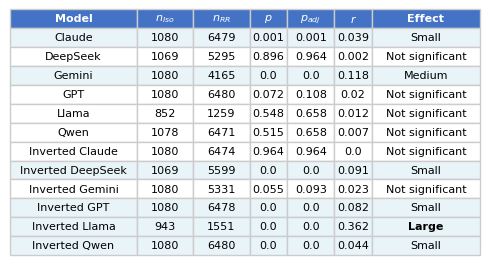

In [38]:
# supplemental table


# Create simplified version with renamed columns
simplified_df = table_df[['label', 'n_x', 'n_y', 'p_value', 'p_adjusted', 'effect_size_r', 'interpretation']].copy()

# Rename columns with LaTeX-style formatting
simplified_df.columns = ['Model', r'$n_{Iso}$', r'$n_{RR}$', r'$p$', r'$p_{adj}$', r'$r$', 'Effect']

# Round numerical values for cleaner display
simplified_df[r'$p$'] = simplified_df[r'$p$'].round(3)
simplified_df[r'$p_{adj}$'] = simplified_df[r'$p_{adj}$'].round(3)
simplified_df[r'$r$'] = simplified_df[r'$r$'].round(3)

# Create the figure
fig, ax = plt.subplots(figsize=(5, 2.75))  
ax.axis('tight')
ax.axis('off')

# Create the table
table = ax.table(cellText=simplified_df.values,
                colLabels=simplified_df.columns,
                cellLoc='center',
                loc='center',
                colWidths=[0.27, 0.12, 0.12, 0.08, 0.10, 0.08, 0.23])

# Style the table
table.auto_set_font_size(False)
table.set_fontsize(8)
table.scale(1, 1)

# Color code by significance (optional - light highlighting)
for i in range(len(simplified_df)):
    if simplified_df.iloc[i]['Effect'] != 'Not significant':
        # Highlight significant results with light blue
        for j in range(len(simplified_df.columns)):
            table[(i+1, j)].set_facecolor('#E8F4F8')
            
        # Make the effect size bold for significant results
        if simplified_df.iloc[i]['Effect'] == 'Large':
            table[(i+1, 6)].set_text_props(weight='bold')

# Style header row
for i in range(len(simplified_df.columns)):
    table[(0, i)].set_facecolor('#4472C4')
    table[(0, i)].set_text_props(weight='bold', color='white')

# Add a subtle grid effect
for i in range(len(simplified_df) + 1):
    for j in range(len(simplified_df.columns)):
        table[(i, j)].set_edgecolor('#CCCCCC')
        table[(i, j)].set_linewidth(1)

plt.tight_layout()
plt.savefig('table_mann_whitney_FDR.png', dpi=300, bbox_inches='tight', facecolor=None)
# plt.savefig('table_mann_whitney_simplified.svg', bbox_inches='tight', facecolor=None)
plt.show()

### Mann Whitney by category

In [39]:
# Mann-Whitney U Test between singles and ring responses per  (final round, excluding hetero ring chats)

import pandas as pd
import numpy as np
from scipy.stats import mannwhitneyu, norm
from IPython.display import display, HTML

results = []

# Extract unique labels from single_by_category for matching
available_labels = single_by_category['label'].unique()

# Define categories
categories = single_df['category'].unique()

for cat in categories:
    for ggb_type in ['GGB', 'GGB_inverted']:
        # Aggregate single answers (x) across all agents for this category and ggb_type
        x = single_df[
            (single_df['category'] == cat) &
            (single_df['label'].str.startswith(ggb_type))
        ]['answer_numeric'].dropna()

        if len(x) < 2:
            continue  # Skip if not enough data for singles

        # For ring answers (y), aggregate across all chat_types matching ggb_type and category
        if ggb_type == 'GGB':
            chat_types = ['ggb_hetero_ring']
        else:
            chat_types = ['ggb_inverted_hetero_ring']

        y = rr_by_agent_df[
            (rr_by_agent_df['round'] == 4) &
            (rr_by_agent_df['chat_type'].isin(chat_types)) &
            (rr_by_agent_df['category'] == cat)
        ]['agent_answer'].dropna()

        if len(y) < 2:
            continue  # Skip if not enough data for ring

        n1 = len(x)
        n2 = len(y)
        stat, p = mannwhitneyu(x, y, alternative='two-sided')

        try:
            mean_u = n1 * n2 / 2
            std_u = np.sqrt(n1 * n2 * (n1 + n2 + 1) / 12)
            z = (stat - mean_u) / std_u
            r = abs(z) / np.sqrt(n1 + n2)
        except:
            r = np.nan

        results.append({
            'category': cat,
            'ggb_type': ggb_type,
            'n_x': n1,
            'n_y': n2,
            'U': stat,
            'p_value': p,
            'effect_size_r': r
        })

results_df = pd.DataFrame(results)

# Round selected float columns
results_df['p_value'] = results_df['p_value'].round(2)
results_df['effect_size_r'] = results_df['effect_size_r'].round(2)

# Sort results by category and ggb_type
results_df = results_df.sort_values(by=['category', 'ggb_type']).reset_index(drop=True)

#print(results_df)
#results_df


In [40]:
# multipletests correction for multiple testing ( Benjamini-Hochberg FDR )
from statsmodels.stats.multitest import multipletests 

# After running all Mann-Whitney U tests and collecting p-values:
p_values = results_df['p_value'].values
 # Your list of p-values
rejected, p_adjusted, _, _ = multipletests(p_values, method='fdr_bh', alpha=0.05)

# Add the adjusted p-values to your dataframe
results_df['p_adjusted'] = p_adjusted

# Optionally, round for cleaner display
results_df['p_adjusted'] = results_df['p_adjusted'].round(3)

# Reorder columns if you want p_adjusted right after p_value
results_df = results_df[['category', 'ggb_type', 'n_x', 'n_y', 'U', 'p_value', 'p_adjusted', 'effect_size_r']]

results_df

,category,ggb_type,n_x,n_y,U,p_value,p_adjusted,effect_size_r
0,IB,GGB,7160,3363,9839800.0,0.00,0.00,0.15
1,IB,GGB_inverted,3573,3383,6770010.5,0.00,0.00,0.10
2,IH,GGB,5411,2644,10818554.5,0.00,0.00,0.42
3,IH,GGB_inverted,2759,2706,3753740.5,0.71,0.71,0.00


In [41]:
# Renaming labels and adding interpretations for effect size
table_df = results_df.copy()
# df to plot labels and colors
df_labels = ['GGB_inverted', 'GGB'] # list(single_by_category.model_name.unique())
plot_labels = ['True', 'False']

df_to_plot_label = dict(zip(df_labels, plot_labels))


####################
##### table_df #####
####################
table_df['Inverted'] = table_df['ggb_type'].apply(lambda x: df_to_plot_label[x])
del table_df['ggb_type']

# add interpretation
table_df['interpretation'] = np.where(
    table_df['p_adjusted'] >= 0.05,
    'Not significant',
    np.where(table_df['effect_size_r'] < 0.1, 'Small',
             np.where(table_df['effect_size_r'] < 0.3, 'Medium', 'Large'))
)


# Concatenate them back (non-inverted first, then inverted)
# table_df = pd.concat([non_inverted, inverted], ignore_index=True)
table_df = table_df[['category', 'Inverted', 'n_x', 'n_y', 'U', 'p_value', 'p_adjusted', 'effect_size_r', 'interpretation']]

table_df

,category,Inverted,n_x,n_y,U,p_value,p_adjusted,effect_size_r,interpretation
0,IB,False,7160,3363,9839800.0,0.00,0.00,0.15,Medium
1,IB,True,3573,3383,6770010.5,0.00,0.00,0.10,Medium
2,IH,False,5411,2644,10818554.5,0.00,0.00,0.42,Large
3,IH,True,2759,2706,3753740.5,0.71,0.71,0.00,Not significant


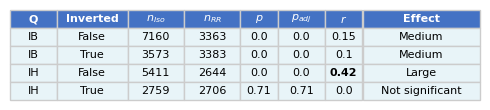

In [42]:
# supplemental table


# Create simplified version with renamed columns
simplified_df = table_df[['category', 'Inverted', 'n_x', 'n_y', 'p_value', 'p_adjusted', 'effect_size_r', 'interpretation']].copy()

# Rename columns with LaTeX-style formatting
simplified_df.columns = ['Q', 'Inverted', r'$n_{Iso}$', r'$n_{RR}$', r'$p$', r'$p_{adj}$', r'$r$', 'Effect']

# Round numerical values for cleaner display
simplified_df[r'$p$'] = simplified_df[r'$p$'].round(3)
simplified_df[r'$p_{adj}$'] = simplified_df[r'$p_{adj}$'].round(3)
simplified_df[r'$r$'] = simplified_df[r'$r$'].round(3)

# Create the figure
fig, ax = plt.subplots(figsize=(5, 1.2))  
ax.axis('tight')
ax.axis('off')

# Create the table
table = ax.table(cellText=simplified_df.values,
                colLabels=simplified_df.columns,
                cellLoc='center',
                loc='center',
                colWidths=[0.1, 0.15, 0.12, 0.12, 0.08, 0.10, 0.08, 0.25])

# Style the table
table.auto_set_font_size(False)
table.set_fontsize(8)
table.scale(1, 1.1)

# Color code by significance (optional - light highlighting)
for i in range(len(simplified_df)):
    if simplified_df.iloc[i]['Effect'] != 'N.S.':
        # Highlight significant results with light blue
        for j in range(len(simplified_df.columns)):
            table[(i+1, j)].set_facecolor('#E8F4F8')
            
        # Make the effect size bold for significant results
        if simplified_df.iloc[i]['Effect'] == 'Large':
            table[(i+1, 6)].set_text_props(weight='bold')

# Style header row
for i in range(len(simplified_df.columns)):
    table[(0, i)].set_facecolor('#4472C4')
    table[(0, i)].set_text_props(weight='bold', color='white')

# Add a subtle grid effect
for i in range(len(simplified_df) + 1):
    for j in range(len(simplified_df.columns)):
        table[(i, j)].set_edgecolor('#CCCCCC')
        table[(i, j)].set_linewidth(1)

plt.tight_layout()
plt.savefig('table_mann_whitney_FDR_by_cat.png', dpi=300, bbox_inches='tight', facecolor=None)
# plt.savefig('table_mann_whitney_simplified.svg', bbox_inches='tight', facecolor=None)
plt.show()

In [43]:
sum([0.1, 0.15, 0.12, 0.12, 0.08, 0.10, 0.08, 0.23])

0.98

### By Cat and Model Bonferrori corrected

In [44]:
single_by_category.head(2)

,model_name,category,label,mean,std,sem,n
0,anthropic/claude-3.5-haiku,IB,GGB_claude,4.206667,1.178815,0.048125,600
1,anthropic/claude-3.5-haiku,IB,GGB_inverted_claude,5.421667,0.899191,0.036709,600


In [45]:
# Mann-Whitney U Test between singles and ring responses per agent (final round, excluding hetero ring chats)
import pandas as pd
import numpy as np
from scipy.stats import mannwhitneyu, norm
from IPython.display import display, HTML

results = []

# Extract unique labels from single_by_category for matching
available_labels = single_by_category['label'].unique()

# Loop over agent_shortnames in rr_by_agent_df
for agent in rr_by_agent_df['agent_shortname'].unique():
    if 'inverted' in agent:
        # e.g. "claude_inverted" -> "GGB_inverted_claude"
        base = agent.replace('_inverted', '')
        label = f'GGB_inverted_{base}'
    else:
        label = f'GGB_{agent}'

    if label not in available_labels:
        print(f'\t {label} not in found, skipping \n')
        continue
    for cat in ['IH', 'IB']:    
        y = rr_by_agent_df[
            (rr_by_agent_df['category'] == cat) &
            (rr_by_agent_df['agent_shortname'] == agent) &
            (rr_by_agent_df['round'] == 4) &
            (~rr_by_agent_df['chat_type'].isin(['ggb_hetero_ring', 'ggb_inverted_hetero_ring']))
        ]['agent_answer'].dropna()
        x = single_df[single_df['label'] == label]['answer_numeric'].dropna()

        if len(x) < 2 or len(y) < 2:
            continue

        n1 = len(x)
        n2 = len(y)
        stat, p = mannwhitneyu(x, y, alternative='two-sided')

        try:
            #z = norm.ppf(1 - p / 2)
            #r = z / np.sqrt(len(x) + len(y))
            # instead Manual z-score calculation for p~0
            mean_u = n1 * n2 / 2
            std_u = np.sqrt(n1 * n2 * (n1 + n2 + 1) / 12)
            z = (stat - mean_u) / std_u

            # Effect size r
            r = abs(z) / np.sqrt(n1 + n2)
        except:
            r = np.nan

        results.append({
            'agent': agent,
            'category': cat,
            'label': label,
            'n_x': len(x),
            'n_y': len(y),
            'U': stat,
            'p_value': p,
            'effect_size_r': r
        })
    
results_df = pd.DataFrame(results)

# Round selected float columns (don't round p-values before bonferroni)
#results_df['p_value'] = results_df['p_value'].round(2)
#results_df['effect_size_r'] = results_df['effect_size_r'].round(2)


# for better display/sorting:
# Create a helper column with base agent name (without "_inverted")
results_df['agent_base'] = results_df['agent'].str.replace('_inverted', '', regex=False)

# Optional: set a consistent order based on unique agent bases
agent_order = results_df['agent_base'].drop_duplicates().tolist()

# Sort by agent base first, then put normal agent before inverted
results_df = results_df.sort_values(
    by=['agent_base', 'agent'],
    key=lambda col: col if col.name != 'agent' else col.apply(lambda x: (x.endswith('_inverted'), x))
).reset_index(drop=True)

# Drop the helper column if not needed
results_df = results_df.drop(columns='agent_base')

#print(results_df)
results_df.head(2)


,agent,category,label,n_x,n_y,U,p_value,effect_size_r
0,claude,IH,GGB_claude,1080,2879,2389819.0,1.951639e-173,0.414369
1,claude,IB,GGB_claude,1080,3600,885864.5,7.265094e-170,0.397170


In [46]:
# multipletests correction for multiple testing ( Benjamini-Hochberg FDR )
from statsmodels.stats.multitest import multipletests 


# After running all Mann-Whitney U tests and collecting p-values:
p_values = results_df['p_value'].values

# # FDR_BH list of p-values
# rejected, p_adjusted, _, _ = multipletests(p_values, method='fdr_bh', alpha=0.05)
# # Add the adjusted p-values to your dataframe
# results_df['p_adjusted'] = p_adjusted


bonferroni_reject, bonferroni_p, _, _  = multipletests(p_values, alpha=0.05, method='bonferroni')
# print("Bonferroni corrected p-values:", bonferroni_results)
results_df['p_adjusted'] = bonferroni_p


# Optionally, round for cleaner display (don't round before significance testing)
# results_df['p_adjusted'] = results_df['p_adjusted'].round(3)

# Reorder columns if you want p_adjusted right after p_value
results_df = results_df[['agent', 'category', 'label', 'n_x', 'n_y', 'U', 'p_value', 'p_adjusted', 'effect_size_r']]

In [47]:
# Renaming labels and adding interpretations for effect size
table_df = results_df.copy()
# df to plot labels and colors
df_labels = ['GGB_claude','GGB_inverted_claude', 'GGB_deepseek',
       'GGB_inverted_deepseek', 'GGB_gemini', 'GGB_inverted_gemini',
       'GGB_inverted_llama', 'GGB_llama', 'GGB_gpt', 'GGB_inverted_gpt',
       'GGB_inverted_qwen', 'GGB_qwen'] # list(single_by_category.model_name.unique())


plot_labels = ['Claude', 'Inverted Claude', 'DeepSeek',
       'Inverted DeepSeek', 'Gemini', 'Inverted Gemini',
       'Inverted Llama', 'Llama', 'GPT', 'Inverted GPT',
       'Inverted Qwen', 'Qwen']
df_to_plot_label = dict(zip(df_labels, plot_labels))


####################
##### table_df #####
####################
table_df['label'] = table_df['label'].apply(lambda x: df_to_plot_label[x])
del table_df['agent']

# add interpretation
table_df['interpretation'] = np.where(
    table_df['p_adjusted'] >= 0.05,
    'N.S.',
    np.where(table_df['effect_size_r'] < 0.1, 'Small',
             np.where(table_df['effect_size_r'] < 0.3, 'Medium', 'Large'))
)

# reorder by inverted 
# Separate inverted and non-inverted
non_inverted = table_df[~table_df['label'].str.contains('Inverted')]
inverted = table_df[table_df['label'].str.contains('Inverted')]

# Concatenate them back (non-inverted first, then inverted)
table_df = pd.concat([non_inverted, inverted], ignore_index=True)

table_df

,category,label,n_x,n_y,U,p_value,p_adjusted,effect_size_r,interpretation
0,IH,Claude,1080,2879,2389819.0,1.951639e-173,4.683933e-172,0.414369,Large
1,IB,Claude,1080,3600,885864.5,7.265094e-170,1.743623e-168,0.397170,Large
2,IH,DeepSeek,1069,2356,2130151.0,7.776593e-290,1.866382e-288,0.554936,Large
3,IB,DeepSeek,1069,2939,693054.5,1.331435e-168,3.195443e-167,0.427992,Large
4,IH,Gemini,1080,2165,1787565.5,1.717440e-144,4.121856e-143,0.431702,Large
5,IB,Gemini,1080,2000,839512.0,6.413120e-26,1.539149e-24,0.184008,Medium
6,IH,GPT,1080,2880,2366224.5,4.037376e-164,9.689702e-163,0.402223,Large
7,IB,GPT,1080,3600,1015622.0,9.412549e-132,2.259012e-130,0.348466,Large
8,IH,Llama,852,616,348544.0,1.749832e-28,4.199597e-27,0.280447,Medium
9,IB,Llama,852,643,179942.0,1.783496e-34,4.280392e-33,0.294101,Medium


#### supp

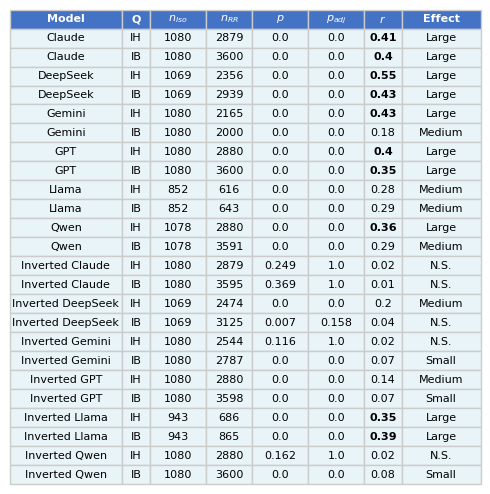

In [48]:
# supplemental table


# Create simplified version with renamed columns
simplified_df = table_df[['label', 'category', 'n_x', 'n_y', 'p_value', 'p_adjusted', 'effect_size_r', 'interpretation']].copy()

# Rename columns with LaTeX-style formatting
simplified_df.columns = ['Model', 'Q', r'$n_{Iso}$', r'$n_{RR}$', r'$p$', r'$p_{adj}$', r'$r$', 'Effect']

# Round p values?
simplified_df[r'$p$'] = simplified_df[r'$p$'].round(3)
simplified_df[r'$p_{adj}$'] = simplified_df[r'$p_{adj}$'].round(3)


# Round effect size
simplified_df[r'$r$'] = simplified_df[r'$r$'].round(2)

# scientific notation for p vals
#simplified_df[r'$p$'] = simplified_df[r'$p$'].apply(lambda x: f"{x:.1e}")
#simplified_df[r'$p_{adj}$'] = simplified_df[r'$p_{adj}$'].apply(lambda x: f"{x:.1e}")


# Create the figure
fig, ax = plt.subplots(figsize=(5, 5))  
ax.axis('tight')
ax.axis('off')

# Create the table
table = ax.table(cellText=simplified_df.values,
                colLabels=simplified_df.columns,
                cellLoc='center',
                loc='center',
                colWidths=[0.24, .06, 0.12, 0.1, 0.12, 0.12, 0.08, 0.17])

# Style the table
table.auto_set_font_size(False)
table.set_fontsize(8)
table.scale(1, 1)

# Color code by significance (optional - light highlighting)
for i in range(len(simplified_df)):
    if simplified_df.iloc[i]['Effect'] != 'Not significant':
        # Highlight significant results with light blue
        for j in range(len(simplified_df.columns)):
            table[(i+1, j)].set_facecolor('#E8F4F8')
            
        # Make the effect size bold for significant results
        if simplified_df.iloc[i]['Effect'] == 'Large':
            table[(i+1, 6)].set_text_props(weight='bold')

# Style header row
for i in range(len(simplified_df.columns)):
    table[(0, i)].set_facecolor('#4472C4')
    table[(0, i)].set_text_props(weight='bold', color='white')

# Add a subtle grid effect
for i in range(len(simplified_df) + 1):
    for j in range(len(simplified_df.columns)):
        table[(i, j)].set_edgecolor('#CCCCCC')
        table[(i, j)].set_linewidth(1)

plt.tight_layout()
plt.savefig('table_mann_whitney_bon_for_all.png', dpi=300, bbox_inches='tight', facecolor=None)
# plt.savefig('table_mann_whitney_simplified.svg', bbox_inches='tight', facecolor=None)
plt.show()

#### Lin Combo Stats

In [ ]:
# single linear combination v hetero RR
import pandas as pd
import numpy as np
from scipy.stats import mannwhitneyu, norm
from IPython.display import display, HTML

results = []

# Extract unique labels from single_by_category for matching
available_labels = single_by_category['label'].unique()

# Define categories
categories = single_df['category'].unique()

for cat in categories:
    for ggb_type in ['GGB', 'GGB_inverted']:
        # Aggregate single answers (x) across all agents for this category and ggb_type
        x = single_df[
            (single_df['category'] == cat) &
            (single_df['label'].str.startswith(ggb_type))
        ]['answer_numeric'].dropna()

        if len(x) < 2:
            continue  # Skip if not enough data for singles

        # For ring answers (y), aggregate across all chat_types matching ggb_type and category
        if ggb_type == 'GGB':
            chat_types = ['ggb_hetero_ring']
        else:
            chat_types = ['ggb_inverted_hetero_ring']

        y = rr_by_agent_df[
            (rr_by_agent_df['round'] == 4) &
            (rr_by_agent_df['chat_type'].isin(chat_types)) &
            (rr_by_agent_df['category'] == cat)
        ]['agent_answer'].dropna()

        if len(y) < 2:
            continue  # Skip if not enough data for ring

        n1 = len(x)
        n2 = len(y)
        stat, p = mannwhitneyu(x, y, alternative='two-sided')

        try:
            mean_u = n1 * n2 / 2
            std_u = np.sqrt(n1 * n2 * (n1 + n2 + 1) / 12)
            z = (stat - mean_u) / std_u
            r = abs(z) / np.sqrt(n1 + n2)
            mean_lc = np.nanmean(x)
            std_x = np.nanstd(x)
            sem_lc = std_x/np.sqrt(n1) 
        except:
            r = np.nan

        results.append({
            'category': cat,
            'ggb_type': ggb_type,
            'n_x': n1,
            'n_y': n2,
            'U': stat,
            'p_value': p,
            'effect_size_r': r,
            'mean_lc': mean_lc,
            'std_lc': std_x,
            'sem_lc': sem_lc
        })

results_df = pd.DataFrame(results)

# Round selected float columns
results_df['p_value'] = results_df['p_value'].round(2)
results_df['effect_size_r'] = results_df['effect_size_r'].round(2)

# Sort results by category and ggb_type
results_df = results_df.sort_values(by=['category', 'ggb_type']).reset_index(drop=True)

#print(results_df)
results_df
lincombo_results_df = results_df

In [51]:
lincombo_results_df

,category,ggb_type,n_x,n_y,U,p_value,effect_size_r,mean_lc,std_lc,sem_lc
0,IB,GGB,7160,3363,9839800.0,0.00,0.15,5.174581,1.395612,0.016493
1,IB,GGB_inverted,3573,3383,6770010.5,0.00,0.10,5.155052,1.404692,0.023500
2,IH,GGB,5411,2644,10818554.5,0.00,0.42,3.473665,2.219893,0.030178
3,IH,GGB_inverted,2759,2706,3753740.5,0.71,0.00,4.550199,2.248659,0.042810


In [ ]:
# Add a boolean 'inverted' column based on whether 'ggb_type' contains 'inverted'
results_df['inverted'] = results_df['ggb_type'].str.contains('inverted', case=False, na=False)

# Sort so that IH categories come first, then by inverted status
results_df['Category_sort'] = results_df['category'].apply(lambda x: 0 if x == 'IH' else 1)
results_df = results_df.sort_values(by=['Category_sort', 'inverted']).reset_index(drop=True)
results_df = results_df.drop(columns='Category_sort')

latex_table = r"""\begin{table}[ht]
\centering
\begin{tabular}{l c c c c c}
\hline
\textbf{GGB Category} & $\mathbf{N_{Singles}}$ & $\mathbf{N_{Round robin}}$ & $\mathbf{U}$ & $\mathbf{p}$ & $\mathbf{r}$ \\
\hline
"""

for _, row in results_df.iterrows():
    cat_name = row['category']
    if row['inverted']:
        cat_name += " inverted"
    latex_table += f"{cat_name} & {int(row['n_x'])} & {int(row['n_y'])} & {int(row['U'])} & {row['p_value']:.2f} & {row['effect_size_r']:.2f} \\\\\n"

latex_table += r"""\hline
\end{tabular}
\caption{Mann–Whitney U test results comparing linear combination/average of single model responses vs. round robin heterogeneous ensembles after response convergence, for original and double-inverted GGB questions.}
\label{tab:statstests_tab_SingleLinearCombvsRingHeterogeneous}
\end{table}
"""

print(latex_table)


\begin{table}[ht]
\centering
\begin{tabular}{l c c c c c}
\hline
\textbf{GGB Category} & $\mathbf{N_{Singles}}$ & $\mathbf{N_{Round robin}}$ & $\mathbf{U}$ & $\mathbf{p}$ & $\mathbf{r}$ \\
\hline
IH & 5411 & 2644 & 10818554 & 0.00 & 0.42 \\
IH inverted & 2759 & 2706 & 3753740 & 0.71 & 0.00 \\
IB & 7160 & 3363 & 9839800 & 0.00 & 0.15 \\
IB inverted & 3573 & 3383 & 6770010 & 0.00 & 0.10 \\
\hline
\end{tabular}
\caption{Mann–Whitney U test results comparing linear combination/average of single model responses vs. round robin heterogeneous ensembles after response convergence, for original and double-inverted GGB questions.}
\label{tab:statstests_tab_SingleLinearCombvsRingHeterogeneous}
\end{table}



# Results - rationale 

## remove off topic responses

In [ ]:
combined_df = combined_df[combined_df['is_response_off_topic'] == False]
exploded_df = exploded_df[exploded_df['is_response_off_topic'] == False]

## SKIP  (testing categories)

In [ ]:
# mapped_categories = {
#     "UTILITARIAN_REASONING": "Utilitarian",
#     "DEONTOLOGICAL_REASONING": "Deontological",
#     "VIRTUE_ETHICS_REASONING": "Virtue Ethics",
#     "CARE_ETHICS_REASONING": "Care Ethics",
#     "FAIRNESS_JUSTICE_REASONING": "Fairness/Justice",
#     "AUTHORITY_BASED_REASONING": "Authority-Based",
#     "LOYALTY_BASED_INGROUP_REASONING": "Loyalty/Ingroup",
#     'LOYALTY_BAIZED_INGROUP_REASONING': "Loyalty/Ingroup", # misspelling
#     "LIBERTY_AUTONOMY_REASONING": "Liberty/Autonomy",
#     "PURITY_SANCTITY_REASONING": "Purity/Sanctity",
#     "HARM_AVOIDANCE_NON_MALEFICENCE": "Harm Avoidance",
#     "SELF_INTEREST_INDIVIDUAL_PRIORITY": "Self-Interest",
    

#     "PEER_PRESSURE_CONVERGENCE": "Peer Pressure",
#     "SYCOPHANCY_EXCESSIVE_AGREEMENT": "Sycophancy",
#     "MAINTAINING_DISSENT_INDEPENDENCE": "Dissent",
#     "EXPLICIT_DISAGREEMENT_COUNTER_ARGUMENT": "Dissent",
#     "CONVERGENCE_TO_SUPERVISOR_FRAMING": "Supervisor Converge",
#     "BUILDING_ON_OTHERS_REASONING": "Build on Others",
#     "PRAGMATIC_BALANCING_CONTEXTUAL": "Balancing",

#     "RISK_ASSESSMENT_PRECAUTIONARY": "Risk Assessment",
#     "LEGALISTIC_POLICY_BASED_REASONING": "Legalistic/Policy",
#     "META_REASONING_CLARIFICATION_FOCUS": "Meta Reasoning",
#     "ANALOGICAL_CASE_BASED_REASONING": "Analogical",
#     "RATIONALE_VAGUE_INCOMPLETE": "Vague/Incomplete",
#     "RATIONALE_CIRCULAR_RESTATING_ANSWER": "Circular",
#     "RATIONALE_TANGENTIAL_IRRELEVANT": "Tangential",
#     "NO_CLEAR_RATIONALE_PROVIDED": "No Rationale"
# }


In [ ]:
### DO NOT DELETE #####

## mapping of categories for plotting (Ram's approach does leave around 118 uncategorized responses but this is a small number - we can make the number smaller to 40 if we also absorb : 
# <!-- 'COLLECTIVE_RESPONSIBILITY', 'COLLECTIVE_ACTION_REASONING', 
#                'ALTRUISM_COMMUNITY_RESPONSIBILITY',
#                'SOCIAL_RESPONSIBILITY','LOYALTY_BAIZED_INGROUP_REASONING']) -->

# or down to 83 jsut by including LOYALTY_BAIZED_INGROUP_REASONING

# ALSO TODO: MAKE SURE THAT THE SELECTED CATEGORIES ARE UPPERCASE!

In [ ]:
## DO NOT DELETE #### 
# combined_df['selected_categories'].apply(lambda x: 'yes' if isinstance(x,list) else x).unique()

# make sure all selected categories nan is actually nan in answers (done and ok!)
# combined_df[combined_df['selected_categories'].isnull()]['answer'].unique()


In [ ]:
# mapped = list(mapped_categories.keys())
# # 'COLLECTIVE_RESPONSIBILITY', 'COLLECTIVE_ACTION_REASONING', 
# #                'ALTRUISM_COMMUNITY_RESPONSIBILITY','SOCIAL_RESPONSIBILITY_ETHICS', 'SOCIAL_JUSTICE',
# #                'SOCIAL_RESPONSIBILITY','SHARED_HUMANITY', 'HUMAN_LIFE_PRESERVATION',
# # mapped.extend(['COLLECTIVE_ACTION_REASONING','SOCIAL_RESPONSIBILITY','COLLECTIVE_RESPONSIBILITY',
# #                'LOYALTY_BAIZED_INGROUP_REASONING'])
# test = combined_df.copy()

# test.dropna(subset = ['selected_categories'], inplace=True)

# # test[test['selected_categories'].isnull()] okay this is empty

# # check that there are no entries that do not have mapped categories 
# test['no category match'] = test['selected_categories'].apply(lambda x: not any([xi.upper() in mapped for xi in x]) if len(x)>0 else False)
# n_nomatch = len(test[test['no category match']])
# print(n_nomatch)
# test[test['no category match']]['group_model'].value_counts()
# test[test['no category match']]['group_type'].value_counts()

In [ ]:
# exploded_test = test[test['no category match']].explode(['selected_categories'])
# exploded_test[exploded_test['selected_categories'] == 'BENEFICENCE_REASONING']['message_content'].unique()
# #test[test['no category match']]['selected_categories']

## Clean up categories and assign new Mappings (exploded_df) for Plotting

In [ ]:
moral_categories = ["Utilitarian",
    "Deontological",
    "Virtue Ethics",
    "Care Ethics",
    "Fairness/Justice",
    "Authority-Based",
    "Loyalty/Ingroup",
    "Liberty/Autonomy",
    "Purity/Sanctity",
    "Harm Avoidance",
    "Self-Interest"]

moral_map = { "UTILITARIAN_REASONING": "Utilitarian",
    "DEONTOLOGICAL_REASONING": "Deontological",
    "VIRTUE_ETHICS_REASONING": "Virtue Ethics",
    "CARE_ETHICS_REASONING": "Care Ethics",
    "FAIRNESS_JUSTICE_REASONING": "Fairness/Justice",
    "AUTHORITY_BASED_REASONING": "Authority-Based",
    "LOYALTY_BASED_INGROUP_REASONING": "Loyalty/Ingroup",
    'LOYALTY_BAIZED_INGROUP_REASONING': "Loyalty/Ingroup", # misspelling
    "LIBERTY_AUTONOMY_REASONING": "Liberty/Autonomy",
    "PURITY_SANCTITY_REASONING": "Purity/Sanctity",
    "HARM_AVOIDANCE_NON_MALEFICENCE": "Harm Avoidance",
    "SELF_INTEREST_INDIVIDUAL_PRIORITY": "Self-Interest"
    }


interaction_categories = ["Peer Pressure",
    "Sycophancy",
    "Dissent",
    "Supervisor Converge",
    "Build on Others",
    "Balancing"]

interaction_map = { "PEER_PRESSURE_CONVERGENCE": "Peer Pressure",
    "SYCOPHANCY_EXCESSIVE_AGREEMENT": "Sycophancy",
    "MAINTAINING_DISSENT_INDEPENDENCE": "Dissent",
    "EXPLICIT_DISAGREEMENT_COUNTER_ARGUMENT": "Dissent",
    "CONVERGENCE_TO_SUPERVISOR_FRAMING": "Supervisor Converge",
    "BUILDING_ON_OTHERS_REASONING": "Build on Others",
    "PRAGMATIC_BALANCING_CONTEXTUAL": "Balancing"
    }

reasoning_categories = ["Risk Assessment",
    "Legalistic/Policy",
    "Meta Reasoning",
    "Analogical",
    "Vague/Incomplete",
    "Circular",
    "Tangential",
    "No Rationale"]

reasoning_map = {"RISK_ASSESSMENT_PRECAUTIONARY": "Risk Assessment",
    "LEGALISTIC_POLICY_BASED_REASONING": "Legalistic/Policy",
    "META_REASONING_CLARIFICATION_FOCUS": "Meta Reasoning",
    "ANALOGICAL_CASE_BASED_REASONING": "Analogical",
    "RATIONALE_VAGUE_INCOMPLETE": "Vague/Incomplete",
    "RATIONALE_CIRCULAR_RESTATING_ANSWER": "Circular",
    "RATIONALE_TANGENTIAL_IRRELEVANT": "Tangential",
    "NO_CLEAR_RATIONALE_PROVIDED": "No Rationale"
    }

mapped_categories = {**moral_map, **reasoning_map, **interaction_map}

all_categories = moral_categories + reasoning_categories + interaction_categories

In [ ]:
exploded_df['plot_category_label'] = exploded_df['selected_categories'].apply(lambda x: mapped_categories.get(x, x))

In [ ]:
# There's still 400 extra entries in combined_df when compared to exploded df... when calculating percentages
# Even after accounting for empty lists and that we dropped nans and empty categories
test_for_combined = exploded_df.copy()
test_for_combined.drop(columns=['selected_categories', 'plot_category_label'],inplace=True)
test_for_combined.drop_duplicates(inplace=True)

a = len(test_for_combined) -   len(combined_df[combined_df['selected_categories'].apply(lambda x: len(x) > 0 and x is not None)])
b = len(test_for_combined) - len(combined_df)

print(f'difference after nan drop: {a}, before nan drop: {b}')

difference after nan drop: -399, before nan drop: -897


## Topological groupings

In [ ]:
exploded_df.columns

Index(['question_id', 'agent_name', 'message_content', 'answer', 'confidence',
       'model_name', 'run_index', 'is_response_off_topic', 'off_topic_reason',
       'selected_categories', 'extracted_answer', 'extracted_confidence',
       'agent_model', 'topology', 'dataset', 'message_index', 'row_index',
       'error_type', 'error_message', 'classification_item_dict',
       'agent_responses_for_row_count', 'original_question',
       'agent_responses_str_snippet', 'question_inverted', 'question_category',
       'group_inverted', 'group_type', 'group_model', 'group_evil',
       'plot_category_label'],
      dtype='object')

In [ ]:
# exploded dfs
exploded_df
n_total = len(combined_df)

# single exploded 
single_explo = exploded_df[exploded_df['group_type'] == 'isolated']
n_single = len(combined_df[combined_df['group_type'] == 'isolated'])

# rr all exploded 
rr_explo= exploded_df[exploded_df['group_type'] == 'ring']
n_rr = len(combined_df[combined_df['group_type'] == 'ring'])

# star (non-evil) exploded 
star_explo = exploded_df[(exploded_df['group_type'] == 'star') & (exploded_df['group_evil'] == False)]
n_star = len(combined_df[(combined_df['group_type'] == 'star') & (combined_df['group_evil'] == False)])

# star (evil) exploded
evil_star_explo = exploded_df[(exploded_df['group_type'] == 'star') & (exploded_df['group_evil'] == True)]
n_evil_star = len(combined_df[(combined_df['group_type'] == 'star') & (combined_df['group_evil'] == True)])

# List of dataframes for overview heatman
group_label_list = ['Total', 'Isolated', 'RR', 'Star', 'RT Star']
group_size_list = [n_total, n_single, n_rr, n_star, n_evil_star]
group_df_list = [exploded_df, single_explo, rr_explo, star_explo, evil_star_explo]

# list of dataframes for round robin only heatmap
rr_group_label_list =[]
rr_group_size_list = [] # [n_rr_comb]
rr_group_df_list = [] # [ex_rr_comb]

for model in combined_df['group_model'].unique():
   this_df = exploded_df[(exploded_df['group_type'] == 'ring') & (exploded_df['group_model'] == model)].copy()
   this_n = len(combined_df[(combined_df['group_type'] == 'ring') & (combined_df['group_model'] == model)])
   rr_group_df_list.append(this_df)
   rr_group_size_list.append(this_n)
   if model == 'mixed':
    rr_group_label_list.append('Hetero')
   elif model =='GPT':
     rr_group_label_list.append('GPT')
   else:
    rr_group_label_list.append(model.capitalize())
   del this_df
   del this_n    

## overview heatmap 

In [ ]:
# heatmap for overview of all off-topic responses
all_cats_heatmap = pd.DataFrame()
for i in range(len(group_label_list)):
    group_label = group_label_list[i]
    group_size = group_size_list[i]
    group_df = group_df_list[i]
    
    # Convert counts to DataFrame
    df = counts_to_df(group_df['plot_category_label'].value_counts(), group_label, group_size)
    
    # Append to the main DataFrame
    all_cats_heatmap = pd.concat([all_cats_heatmap, df], ignore_index=True)


# pivot the dataframe for heatmap - also need to reindex for presentation
all_cats_heatmap['group'] = all_cats_heatmap['group'].apply(lambda x: 'RT STAR\n(GPT)' if x=='RT Star' else x)

pivoted = all_cats_heatmap.pivot(index="plot_category_label", columns="group", values="percentage")
pivoted = pivoted.reindex(columns=['Total','Isolated', 'RR', 'Star', 'RT STAR\n(GPT)'])
pivoted = pivoted.reindex(index= all_categories)

# pivoted = all_cats_heatmap.pivot(index="plot_category_label", columns="group", values="percentage")
# pivoted = pivoted.reindex(columns=['Total','Isolated', 'RR', 'Star', 'RT STAR\n(GPT)'])
# pivoted = pivoted.reindex(index= all_categories)

In [ ]:
pivoted

group,Total,Isolated,RR,Star,RT STAR\n(GPT)
plot_category_label,,,,,
Utilitarian,16.479138,27.925154,16.940328,13.761384,11.472931
Deontological,36.025592,34.051792,34.486923,42.184467,39.035878
Virtue Ethics,1.564616,2.526449,1.268291,2.476841,2.378322
Care Ethics,6.723884,10.768988,6.069437,8.444190,8.420073
Fairness/Justice,4.307506,5.345018,4.156988,4.921109,3.645985
Authority-Based,0.615921,0.094742,0.596100,0.863832,0.267489
Loyalty/Ingroup,1.891592,4.350229,1.897046,1.602585,1.267663
Liberty/Autonomy,12.895154,14.937628,12.259943,15.300126,12.647555
Purity/Sanctity,1.237176,0.426338,0.816672,2.986280,1.965459


In [ ]:
# heatmap for round roubin specifically
heatmap_rr_df = pd.DataFrame()
for i in range(len(rr_group_label_list)):
    group_label = rr_group_label_list[i]
    group_size = rr_group_size_list[i]
    group_df = rr_group_df_list[i]
    
    # Convert counts to DataFrame
    df = counts_to_df(group_df['plot_category_label'].value_counts(), group_label, group_size)
    
    # Append to the main DataFrame
    heatmap_rr_df = pd.concat([heatmap_rr_df, df], ignore_index=True)

# pivot the dataframe for heatmap
pivoted_rr = heatmap_rr_df.pivot(index="plot_category_label", columns="group", values="percentage")
pivoted_rr = pivoted_rr.reindex(columns=['Hetero', 'GPT', 'Llama', 'Claude', 'Gemini', 'Qwen', 'Deepseek'])
pivoted_rr = pivoted_rr.reindex(index=all_categories)



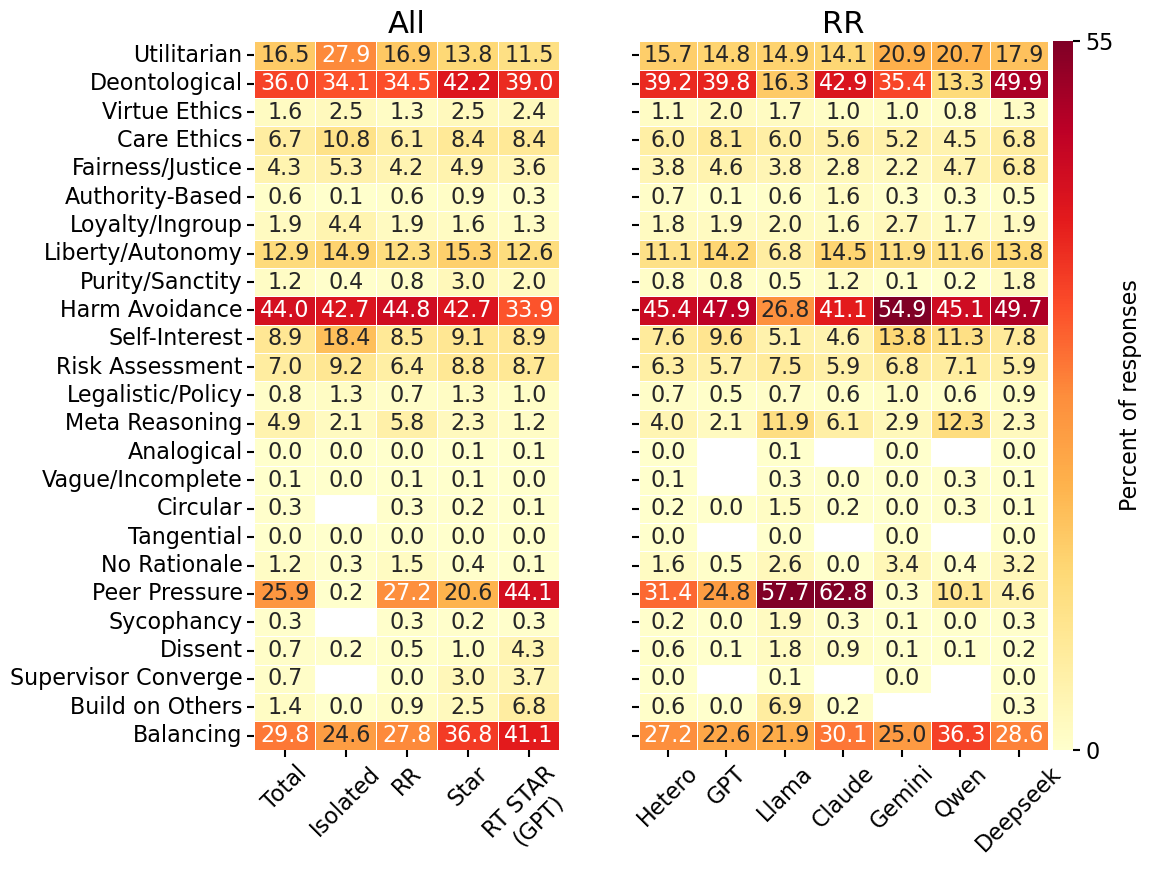

In [ ]:
max_color = 55

# Draw a heatmap with the numeric values in each cell
fig, axs = plt.subplots(ncols = 2, figsize=(11.25, 9.2), sharey=True, gridspec_kw={'width_ratios': [5, 8]})


# plt.suptitle('Rationale (%)', fontsize=text_size)
ax = axs[0]
hm = sns.heatmap(pivoted, annot=True, fmt=".1f", linewidths=.5, ax=ax, 
                 cmap='YlOrRd',annot_kws={"size": tick_size},cbar = False,vmin=0, vmax=max_color)
                 #cbar_kws = {'orientation':'horizontal', 'location':'bottom', 'pad':.25, 'fraction': .3})
hm.tick_params(labelsize=tick_size)
hm.set_xticklabels(hm.get_xticklabels(), rotation=45)

ax.set_title('All', fontsize=text_size) 
ax.set_xlabel('')
ax.set_ylabel('')

ax1 = axs[1]
hm = sns.heatmap(pivoted_rr, annot=True, fmt=".1f", linewidths=.5, ax=ax1, 
                 cmap='YlOrRd',annot_kws={"size": tick_size},cbar = True, vmin=0, vmax=max_color,
                 cbar_kws={'location': 'right', 'orientation': 'vertical', 'pad':0.01, 'label':'Percent of responses', 'ticks':[0,max_color], 'aspect': 35})

# colorbar label
hm.figure.axes[-1].yaxis.label.set_size(tick_size)
# colorbar ticks
cbar = hm.collections[0].colorbar
cbar.ax.tick_params(labelsize=tick_size)

# colorbar label
ax1.figure.axes[-1].yaxis.label.set_size(tick_size)
# colorbar ticks
cbar = hm.collections[0].colorbar
cbar.ax.tick_params(labelsize=tick_size)

hm.tick_params(labelsize=tick_size)
hm.set_xticklabels(hm.get_xticklabels(), rotation=45)
ax1.set_title('RR', fontsize=text_size) 
ax1.set_xlabel('')
ax1.set_ylabel('')


fig.savefig('figures/all_and_rr.svg', bbox_inches='tight')

## Non-inverted star v homo v hetero heatmaps

In [ ]:
# 1. Heterogeneous ring groups (mixed models)
hetero_exploded = exploded_df[(
    (exploded_df['group_type'] == 'ring') & 
    (exploded_df['group_model'] == 'mixed') &
    (exploded_df['group_evil'] == False) &
    (exploded_df['question_inverted'] == False)
    )]
hetero_combined = combined_df[(
    (combined_df['group_type'] == 'ring') & 
    (combined_df['group_model'] == 'mixed') &
    (combined_df['group_evil'] == False) & 
    (combined_df['question_inverted'] == False)
    )]

# 2. Star topologies
star_gpt_explo = exploded_df[(
    (exploded_df['group_type'] == 'star') & 
    (exploded_df['group_evil'] == False) &
    (exploded_df['group_model'] == 'GPT') & 
    (exploded_df['question_inverted'] == False)
    )]
star_gpt = combined_df[(
    (combined_df['group_type'] == 'star') & 
    (combined_df['group_evil'] == False) &
    (combined_df['group_model'] == 'GPT') & 
    (combined_df['question_inverted'] == False)
    )]

star_rt_explo = exploded_df[(
    (exploded_df['group_type'] == 'star') & 
    (exploded_df['group_evil'] == True) &
    (exploded_df['group_model'] == 'GPT') & 
    (exploded_df['question_inverted'] == False)
    )]
star_rt = combined_df[(
    (combined_df['group_type'] == 'star') & 
    (combined_df['group_evil'] == True) &
    (combined_df['group_model'] == 'GPT') & 
    (combined_df['question_inverted'] == False)
    )]


star_qwen_explo = exploded_df[(
    (exploded_df['group_type'] == 'star') & 
    (exploded_df['group_evil'] == False) &
    (exploded_df['group_model'] == 'qwen') & 
    (exploded_df['question_inverted'] == False)
    )]

star_qwen = combined_df[(
    (combined_df['group_type'] == 'star') & 
    (combined_df['group_evil'] == False) &
    (combined_df['group_model'] == 'qwen') & 
    (combined_df['question_inverted'] == False)
    )]

# 3. rr homogeneous groups (ring homo)
gpt_rr_expl = exploded_df[(
    (exploded_df['group_type'] == 'ring') &
    (exploded_df['group_model'] == 'GPT') &
    (exploded_df['group_evil'] == False) & 
    (exploded_df['question_inverted'] == False)
    )]

gpt_rr = combined_df[(
    (combined_df['group_type'] == 'ring') &
    (combined_df['group_model'] == 'GPT') &
    (combined_df['group_evil'] == False)  & 
    (combined_df['question_inverted'] == False)
    )]


qwen_rr_expl = exploded_df[(
    (exploded_df['group_type'] == 'ring') &
    (exploded_df['group_model'] == 'qwen') &
    (exploded_df['group_evil'] == False) & 
    (exploded_df['question_inverted'] == False)
    )]


qwen_rr = combined_df[(
    (combined_df['group_type'] == 'ring') &
    (combined_df['group_model'] == 'qwen') &
    (combined_df['group_evil'] == False) & 
    (combined_df['question_inverted'] == False)
    )]


# list of dataframes for heatmap
group_label_list =['Hetero', 'Star GPT', 'RT Star\n(GPT)', 'Star Qwen', 'RR GPT', 'RR Qwen']
group_size_list = [len(hetero_combined), len(star_gpt), len(star_rt), len(star_qwen), len(gpt_rr), len(qwen_rr)] # [n_rr_comb]
group_df_list = [hetero_exploded,star_gpt_explo,star_rt_explo, star_qwen_explo, gpt_rr_expl, qwen_rr_expl] # [ex_rr_comb]


In [ ]:
all_cats_heatmap = pd.DataFrame()
for i in range(len(group_label_list)):
    group_label = group_label_list[i]
    group_size = group_size_list[i]
    group_df = group_df_list[i]
    
    # Convert counts to DataFrame
    df = counts_to_df(group_df['plot_category_label'].value_counts(), group_label, group_size)
    
    # Append to the main DataFrame
    all_cats_heatmap = pd.concat([all_cats_heatmap, df], ignore_index=True)


# pivot the dataframe for heatmap - also need to reindex for presentation
all_cats_heatmap['group'] = all_cats_heatmap['group'].apply(lambda x: 'RT STAR\n(GPT)' if x=='RT Star' else x)

pivoted = all_cats_heatmap.pivot(index="plot_category_label", columns="group", values="percentage")
pivoted = pivoted.reindex(columns=['Star Qwen','RR Qwen', 'Hetero', 'RR GPT', 'Star GPT', 'RT Star\n(GPT)'])
pivoted = pivoted.reindex(index= interaction_categories)


In [ ]:
pivoted

group,Star Qwen,RR Qwen,Hetero,RR GPT,Star GPT,RT Star\n(GPT)
plot_category_label,,,,,,
Peer Pressure,50.737382,10.622882,33.240078,27.982253,7.168138,44.065825
Sycophancy,0.520505,0.046745,0.355701,0.081019,0.112792,0.255859
Dissent,2.815457,0.070118,0.495584,0.061728,0.070009,4.291446
Supervisor Converge,3.004732,NaN,NaN,NaN,4.822838,3.651800
Build on Others,1.600946,NaN,0.703409,0.046296,3.955505,6.780252
Balancing,37.239748,41.408593,33.435914,25.443673,41.173039,41.111822


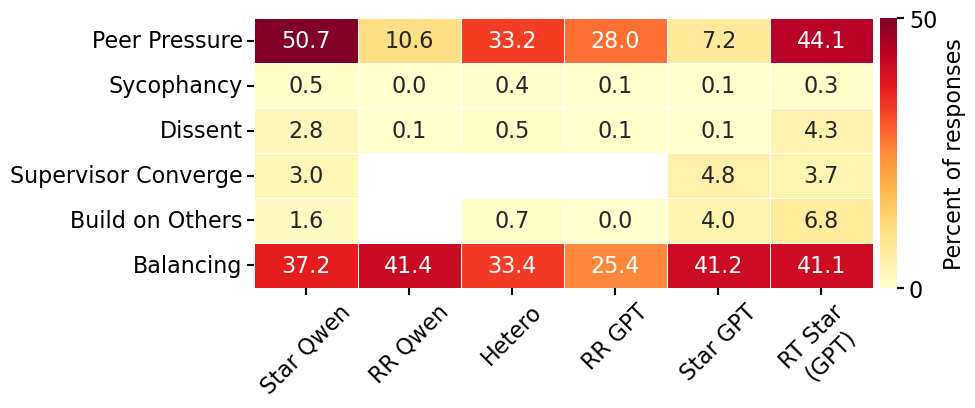

In [ ]:
max_color = 50

# Draw a heatmap with the numeric values in each cell
fig, ax = plt.subplots(ncols = 1, figsize=(9.5, 3.5 ))


hm = sns.heatmap(pivoted, annot=True, fmt=".1f", linewidths=.5, ax=ax, 
                 cmap='YlOrRd',annot_kws={"size": tick_size},cbar = True, vmin=0, vmax=max_color,
                 cbar_kws={'location': 'right', 'orientation': 'vertical', 'pad':0.01, 'label':'Percent of responses', 'ticks':[0,max_color], 'aspect': 16})

hm.tick_params(labelsize=tick_size)
hm.set_xticklabels(hm.get_xticklabels(), rotation=45)

# ax.set_title('All', fontsize=text_size) 
ax.set_xlabel('')
ax.set_ylabel('')

# colorbar label
hm.figure.axes[-1].yaxis.label.set_size(tick_size)
# colorbar ticks
cbar = hm.collections[0].colorbar
cbar.ax.tick_params(labelsize=tick_size)




fig.savefig('figures/star_heatmap.svg', bbox_inches='tight')

# Reslts- HCISS

## GPT (3 line heatmap) - only original Qs

In [ ]:
i
# 1. Heterogeneous ring groups (mixed models)
hetero_exploded = exploded_df[(
    (exploded_df['group_type'] == 'ring') & 
    (exploded_df['group_model'] == 'mixed') &
    (exploded_df['group_evil'] == False) 
    # &
    # (exploded_df['question_inverted'] == False)
    )]
hetero_combined = combined_df[(
    (combined_df['group_type'] == 'ring') & 
    (combined_df['group_model'] == 'mixed') &
    (combined_df['group_evil'] == False) 
    # & 
    # (combined_df['question_inverted'] == False)
    )]

# 2. Star GPT
star_gpt_explo = exploded_df[(
    (exploded_df['group_type'] == 'star') & 
    (exploded_df['group_evil'] == False) &
    (exploded_df['group_model'] == 'GPT') 
    # & 
    # (exploded_df['question_inverted'] == False)
    )]
star_gpt = combined_df[(
    (combined_df['group_type'] == 'star') & 
    (combined_df['group_evil'] == False) &
    (combined_df['group_model'] == 'GPT') 
    # & 
    # (combined_df['question_inverted'] == False)
    )]


# 3. rr homogeneous groups (ring homo)
gpt_rr_expl = exploded_df[(
    (exploded_df['group_type'] == 'ring') &
    (exploded_df['group_model'] == 'GPT') &
    (exploded_df['group_evil'] == False) 
    # & 
    # (exploded_df['question_inverted'] == False)
    )]

gpt_rr = combined_df[(
    (combined_df['group_type'] == 'ring') &
    (combined_df['group_model'] == 'GPT') &
    (combined_df['group_evil'] == False)  
    # & 
    # (combined_df['question_inverted'] == False)
    )]


# list of dataframes for heatmap
group_label_list =['Hetero RR', 'Star GPT', 'RR GPT']
group_size_list = [len(hetero_combined), len(star_gpt),  len(gpt_rr)] # [n_rr_comb]
group_df_list = [hetero_exploded,star_gpt_explo, gpt_rr_expl] # [ex_rr_comb]

In [ ]:

all_cats_heatmap = pd.DataFrame()
for i in range(len(group_label_list)):
    group_label = group_label_list[i]
    group_size = group_size_list[i]
    group_df = group_df_list[i]
    
    # Convert counts to DataFrame
    df = counts_to_df(group_df['plot_category_label'].value_counts(), group_label, group_size)
    
    # Append to the main DataFrame
    all_cats_heatmap = pd.concat([all_cats_heatmap, df], ignore_index=True)

# pivot the dataframe for heatmap - also need to reindex for presentation

pivoted = all_cats_heatmap.pivot(index="plot_category_label", columns="group", values="percentage")
pivoted = pivoted.reindex(columns=['Hetero RR', 'Star GPT', 'RR GPT'])
pivoted = pivoted.reindex(index= all_categories)



In [ ]:
pivoted_transposed = all_cats_heatmap.pivot(index="group", columns="plot_category_label", values="percentage")
pivoted_transposed = pivoted_transposed.reindex(columns=all_categories)
pivoted_transposed = pivoted_transposed.reindex(index= ['Hetero RR', 'Star GPT', 'RR GPT'])

In [ ]:
xthickness = 1.25
axticklength = 2.5
rcParams["ytick.major.size"] = axticklength
rcParams["xtick.major.size"] = axticklength
rcParams["text.usetex"]=False
rcParams['axes.linewidth'] = axthickness
plt.rcParams['xtick.major.width'] = axthickness
plt.rcParams['ytick.major.width'] = axthickness

text_size = 22
tick_size = 16
capsize = 5
markersize = 4

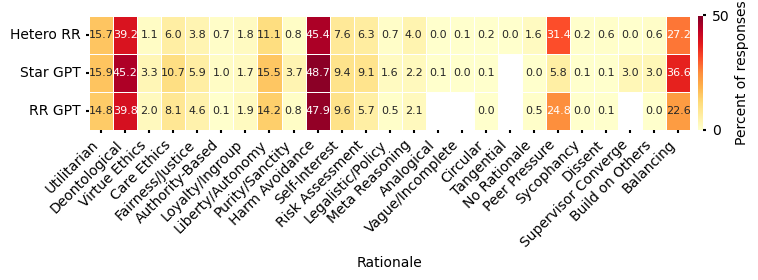

In [ ]:
fig, ax = plt.subplots(figsize=(8.25, 2.9))

label_size= 8
text_size = 12
tick_size = 10
capsize = 5
markersize = 4

hm = sns.heatmap(pivoted_transposed, annot=True, fmt=".1f", linewidths=.7, ax=ax, 
                 cmap='YlOrRd', annot_kws={"size": label_size}, cbar=True, vmin=0, vmax=max_color,
                 cbar_kws={'location': 'right', 'orientation': 'vertical', 'pad':0.01, 
                          'label':'Percent of responses', 'ticks':[0, max_color], 'aspect': 20})

# Colorbar label
hm.figure.axes[-1].yaxis.label.set_size(tick_size)
# Colorbar ticks
cbar = hm.collections[0].colorbar
cbar.ax.tick_params(labelsize=tick_size)

# Axis styling
hm.tick_params(labelsize=tick_size)
hm.set_xticklabels(hm.get_xticklabels(), rotation=45, ha='right')
hm.set_yticklabels(hm.get_yticklabels(), rotation=0)

ax.set_ylabel('')
# ax.set_ylabel('Group Types', fontsize=text_size)
ax.set_xlabel('Rationale')
# ax.set_title('Rationale Distribution Across Groups', fontsize=text_size)

plt.tight_layout()
fig.savefig('figures/gpt_groups_comparison_allQs.png', bbox_inches='tight', dpi = 300)
plt.show()

## Figures 4-6 consolidate

1 main figure + Amplification Supp

## New Figure : Overview , RR, Star for select categories

### Heatmap: DFs for Overview

In [ ]:
# Overview

# 1. Isolated groups (mixed models)
iso_exploded = exploded_df[(
    (exploded_df['group_type'] == 'isolated') & 
    (exploded_df['group_evil'] == False) 
    # &
    # (exploded_df['question_inverted'] == False)
    )]
iso_combined = combined_df[(
    (combined_df['group_type'] == 'isolated') & 
    (combined_df['group_evil'] == False) 
    # & 
    # (combined_df['question_inverted'] == False)
    )]

# 2. Heterogeneous ring groups (mixed models)
hetero_exploded = exploded_df[(
    (exploded_df['group_type'] == 'ring') & 
    (exploded_df['group_model'] == 'mixed') &
    (exploded_df['group_evil'] == False) 
    # &
    # (exploded_df['question_inverted'] == False)
    )]
hetero_combined = combined_df[(
    (combined_df['group_type'] == 'ring') & 
    (combined_df['group_model'] == 'mixed') &
    (combined_df['group_evil'] == False) 
    # & 
    # (combined_df['question_inverted'] == False)
    )]

# 3. Homo ring groups 
homo_exploded = exploded_df[(
    (exploded_df['group_type'] == 'ring') & 
    (exploded_df['group_model'] != 'mixed') &
    (exploded_df['group_evil'] == False) 
    # &
    # (exploded_df['question_inverted'] == False)
    )]
homo_combined = combined_df[(
    (combined_df['group_type'] == 'ring') & 
    (combined_df['group_model'] != 'mixed') &
    (combined_df['group_evil'] == False) 
    # & 
    # (combined_df['question_inverted'] == False)
    )]

# 4. Star Combined
star_exploded = exploded_df[(
    (exploded_df['group_type'] == 'star') & 
    (exploded_df['group_evil'] == False) 
    )]

star_combined = combined_df[(
    (combined_df['group_type'] == 'star') & 
    (combined_df['group_evil'] == False) 
    )]


# list of dataframes for heatmap
overview_label_list =['Isolated', 'Homo RR', 'Hetro RR', 'Star']
overview_size_list = [len(iso_combined), len(homo_combined),  len(hetero_combined), len(star_combined)] # 
overview_df_list = [iso_exploded,homo_exploded, hetero_exploded, star_exploded] # [ex_rr_comb]

# heatmap for ISO specifically
heatmap_overview_df = pd.DataFrame()
for i in range(len(overview_label_list)):
    group_label = overview_label_list[i]
    group_size = overview_size_list[i]
    group_df = overview_df_list[i]
    
    # Convert counts to DataFrame
    df = counts_to_df(group_df['plot_category_label'].value_counts(), group_label, group_size)
    
    # Append to the main DataFrame
    heatmap_overview_df = pd.concat([heatmap_overview_df, df], ignore_index=True)

### Heatmap DFs: star

In [ ]:
# 1. Star Qwen
star_qwen_explo = exploded_df[(
    (exploded_df['group_type'] == 'star') & 
    (exploded_df['group_evil'] == False) &
    (exploded_df['group_model'] == 'qwen') 
    # & 
    # (exploded_df['question_inverted'] == False)
    )]
star_qwen_comb = combined_df[(
    (combined_df['group_type'] == 'star') & 
    (combined_df['group_evil'] == False) &
    (combined_df['group_model'] == 'qwen') 
    # & 
    # (combined_df['question_inverted'] == False)
    )]

# 2. Star GPT
star_gpt_explo = exploded_df[(
    (exploded_df['group_type'] == 'star') & 
    (exploded_df['group_evil'] == False) &
    (exploded_df['group_model'] == 'GPT') 
    # & 
    # (exploded_df['question_inverted'] == False)
    )]
star_gpt_comb = combined_df[(
    (combined_df['group_type'] == 'star') & 
    (combined_df['group_evil'] == False) &
    (combined_df['group_model'] == 'GPT') 
    # & 
    # (combined_df['question_inverted'] == False)
    )]

# 2. Star GPT (RT)
star_rt_explo = exploded_df[(
    (exploded_df['group_type'] == 'star') & 
    (exploded_df['group_evil'] == True) &
    (exploded_df['group_model'] == 'GPT') 
    # & 
    # (exploded_df['question_inverted'] == False)
    )]
star_rt_comb = combined_df[(
    (combined_df['group_type'] == 'star') & 
    (combined_df['group_evil'] == True) &
    (combined_df['group_model'] == 'GPT') 
    # & 
    # (combined_df['question_inverted'] == False)
    )]

# list of dataframes for heatmap
star_label_list =['Qwen', 'GPT', 'RT (GPT)']
star_size_list = [len(star_qwen_comb), len(star_gpt_comb),  len(star_rt_comb)] # 
star_df_list = [star_qwen_explo, star_gpt_explo, star_rt_explo] # [ex_rr_comb]

# heatmap for ISO specifically
heatmap_star_df = pd.DataFrame()
for i in range(len(star_label_list)):
    group_label = star_label_list[i]
    group_size = star_size_list[i]
    group_df = star_df_list[i]
    
    # Convert counts to DataFrame
    df = counts_to_df(group_df['plot_category_label'].value_counts(), group_label, group_size)
    
    # Append to the main DataFrame
    heatmap_star_df = pd.concat([heatmap_star_df, df], ignore_index=True)

### Heatmap DFs: Isolated by Model

In [ ]:
# heatmap for ISOLATED specifically
# list of dataframes for round robin only heatmap
iso_group_label_list =[]
iso_group_size_list = [] # [n_rr_comb]
iso_group_df_list = [] # [ex_rr_comb]

for model in combined_df['group_model'].unique():
   this_df = exploded_df[(exploded_df['group_type'] == 'isolated') & (exploded_df['group_model'] == model)].copy()
   this_n = len(combined_df[(combined_df['group_type'] == 'isolated') & (combined_df['group_model'] == model)])
   iso_group_df_list.append(this_df)
   iso_group_size_list.append(this_n)
   if model == 'mixed':
    iso_group_label_list.append('Hetero')
   elif model =='GPT':
     iso_group_label_list.append('GPT')
   else:
    iso_group_label_list.append(model.capitalize())
   del this_df
   del this_n    

# heatmap for ISO specifically
heatmap_iso_df = pd.DataFrame()
for i in range(len(iso_group_label_list)):
    group_label = iso_group_label_list[i]
    group_size = iso_group_size_list[i]
    group_df = iso_group_df_list[i]
    
    # Convert counts to DataFrame
    df = counts_to_df(group_df['plot_category_label'].value_counts(), group_label, group_size)
    
    # Append to the main DataFrame
    heatmap_iso_df = pd.concat([heatmap_iso_df, df], ignore_index=True)

### Heatmap DFs: RR by group

In [ ]:
# heatmap for RR specifically
heatmap_rr_df = pd.DataFrame()
for i in range(len(rr_group_label_list)):
    group_label = rr_group_label_list[i]
    group_size = rr_group_size_list[i]
    group_df = rr_group_df_list[i]
    
    # Convert counts to DataFrame
    df = counts_to_df(group_df['plot_category_label'].value_counts(), group_label, group_size)
    
    # Append to the main DataFrame
    heatmap_rr_df = pd.concat([heatmap_rr_df, df], ignore_index=True)

# pivot the dataframe for heatmap
pivoted_rr = heatmap_rr_df.pivot(index="plot_category_label", columns="group", values="percentage")
pivoted_rr = pivoted_rr.reindex(columns=['Hetero', 'GPT', 'Llama', 'Claude', 'Gemini', 'Qwen', 'Deepseek'])
pivoted_rr = pivoted_rr.reindex(index=all_categories)



### selected categories

In [ ]:
# all_categories = moral_categories + reasoning_categories + interaction_categories
# reasoning_categories

In [ ]:
# selected_categories = ['Self-Interest','Harm Avoidance'] + ['Meta Reasoning', 'Circular'] + interaction_categories # for supp fig
selected_categories = ['Self-Interest'] + interaction_categories # (for in paper fig)

### pivot dfs for plotting

In [ ]:
## OVERVIEW
pivoted_overview = heatmap_overview_df.pivot(index="plot_category_label", columns="group", values="percentage")
pivoted_overview = pivoted_overview.reindex(columns=['Isolated', 'Homo RR', 'Hetro RR', 'Star'])
pivoted_overview = pivoted_overview.reindex(index=selected_categories)

In [ ]:
# RR pivot the dataframe for heatmap
pivoted_rr = heatmap_rr_df.pivot(index="plot_category_label", columns="group", values="percentage")
pivoted_rr = pivoted_rr.reindex(columns=['Llama', 'Claude', 'Gemini', 'Deepseek','Qwen', 'GPT'])
pivoted_rr = pivoted_rr.reindex(index=selected_categories)

# for supp
pivoted_rr_T = heatmap_rr_df.pivot(columns="plot_category_label", index="group", values="percentage")
pivoted_rr_T = pivoted_rr_T.reindex(index=['Llama', 'Claude', 'Gemini', 'Deepseek','Qwen', 'GPT'])
pivoted_rr_T = pivoted_rr_T.reindex(columns = selected_categories)

In [ ]:
# ISO pivot (for supp)
# heatmap_iso_df.group.unique()
pivoted_iso = heatmap_iso_df.pivot(index="plot_category_label", columns="group", values="percentage")
pivoted_iso = pivoted_iso.reindex(columns=['Llama', 'Claude', 'Gemini', 'Deepseek','Qwen', 'GPT'])
pivoted_iso = pivoted_iso.reindex(index=selected_categories)

# for supp
pivoted_iso_T = heatmap_iso_df.pivot(columns="plot_category_label", index="group", values="percentage")
pivoted_iso_T = pivoted_iso.reindex(index=['Llama', 'Claude', 'Gemini', 'Deepseek','Qwen', 'GPT'])
pivoted_iso_T = pivoted_iso.reindex(columns = selected_categories)

In [ ]:
# STAR pivot 
# heatmap_star_df.group.unique()
pivoted_star = heatmap_star_df.pivot(index="plot_category_label", columns="group", values="percentage")
pivoted_star = pivoted_star.reindex(columns=['Qwen', 'GPT', 'RT (GPT)'])
pivoted_star = pivoted_star.reindex(index=selected_categories)

### Plotting 

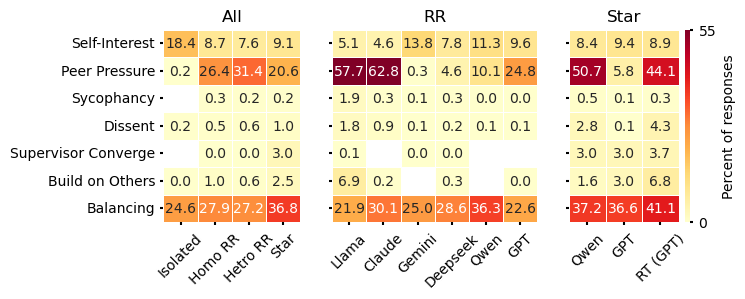

In [ ]:
max_color = 55

# Draw a heatmap with the numeric values in each cell
fig, axs = plt.subplots(ncols = 3, figsize=(7, 2.5), sharey=True, gridspec_kw={'width_ratios': [4, 6, 4]})


# plt.suptitle('Rationale (%)', fontsize=text_size)
ax = axs[0]
hm = sns.heatmap(pivoted_overview, annot=True, fmt=".1f", linewidths=.5, ax=ax, 
                 cmap='YlOrRd',annot_kws={"size": tick_size},cbar = False,vmin=0, vmax=max_color)
                 #cbar_kws = {'orientation':'horizontal', 'location':'bottom', 'pad':.25, 'fraction': .3})
hm.tick_params(labelsize=tick_size)
hm.set_xticklabels(hm.get_xticklabels(), rotation=45)

ax.set_title('All', fontsize=text_size) 
ax.set_xlabel('')
ax.set_ylabel('')

ax1 = axs[1]
hm = sns.heatmap(pivoted_rr, annot=True, fmt=".1f", linewidths=.5, ax=ax1, 
                 cmap='YlOrRd',annot_kws={"size": tick_size},cbar = False, vmin=0, vmax=max_color)
                #  cbar_kws={'location': 'right', 'orientation': 'vertical', 'pad':0.01, 'label':'Percent of responses', 'ticks':[0,max_color], 'aspect': 35})
hm.tick_params(labelsize=tick_size)
hm.set_xticklabels(hm.get_xticklabels(), rotation=45)



ax2 = axs[2]
hm = sns.heatmap(pivoted_star, annot=True, fmt=".1f", linewidths=.5, ax=ax2, 
                 cmap='YlOrRd',annot_kws={"size": tick_size},cbar = True, vmin=0, vmax=max_color,
                 cbar_kws={'location': 'right', 'orientation': 'vertical', 'pad':0.05, 'label':'Percent of responses', 'ticks':[0,max_color], 'aspect': 40})

# # colorbar label
# hm.figure.axes[-1].yaxis.label.set_size(tick_size)
# # colorbar ticks
# cbar = hm.collections[0].colorbar
# cbar.ax.tick_params(labelsize=tick_size)

# colorbar label
ax2.figure.axes[-1].yaxis.label.set_size(tick_size)
# colorbar ticks
cbar = hm.collections[0].colorbar
cbar.ax.tick_params(labelsize=tick_size)

hm.tick_params(labelsize=tick_size)
hm.set_xticklabels(hm.get_xticklabels(), rotation=45)
ax1.set_title('RR', fontsize=text_size) 
ax1.set_xlabel('')
ax1.set_ylabel('')

ax2.set_title('Star', fontsize=text_size) 
ax2.set_xlabel('')
ax2.set_ylabel('')

# fig.savefig('figures/new_heatmaps.svg', bbox_inches='tight')
fig.savefig('figures/select_category_heatmaps.png', bbox_inches='tight', dpi=300)

### Supp : RR v Iso

Text(326.17883379247013, 0.5, '')

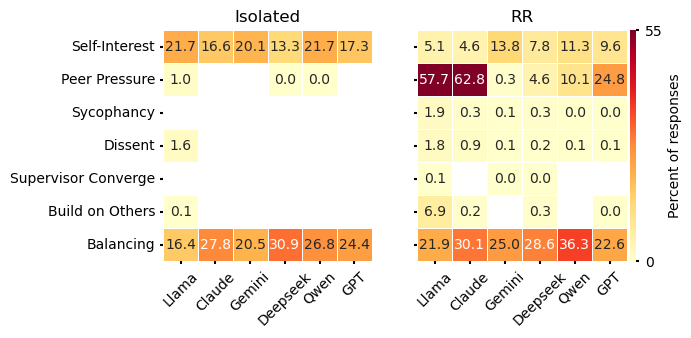

In [ ]:
max_color = 55

# Draw a heatmap with the numeric values in each cell
fig, axs = plt.subplots(ncols = 2, figsize=(6.5,3), sharey=True, gridspec_kw={'width_ratios': [5, 6]})


# plt.suptitle('Rationale (%)', fontsize=text_size)
ax = axs[0]
hm = sns.heatmap(pivoted_iso, annot=True, fmt=".1f", linewidths=.5, ax=ax, 
                 cmap='YlOrRd',annot_kws={"size": tick_size},cbar = False,vmin=0, vmax=max_color)
                 #cbar_kws = {'orientation':'horizontal', 'location':'bottom', 'pad':.25, 'fraction': .3})
hm.tick_params(labelsize=tick_size)
hm.set_xticklabels(hm.get_xticklabels(), rotation=45)

ax.set_title('Isolated', fontsize=text_size) 
ax.set_xlabel('')
ax.set_ylabel('')

ax1 = axs[1]
hm = sns.heatmap(pivoted_rr, annot=True, fmt=".1f", linewidths=.5, ax=ax1, 
                 cmap='YlOrRd',annot_kws={"size": tick_size},cbar = True, vmin=0, vmax=max_color,
                 cbar_kws={'location': 'right', 'orientation': 'vertical', 'pad':0.01, 'label':'Percent of responses', 'ticks':[0,max_color], 'aspect': 35})
hm.tick_params(labelsize=tick_size)
hm.set_xticklabels(hm.get_xticklabels(), rotation=45)


# # colorbar label
hm.figure.axes[-1].yaxis.label.set_size(tick_size)
# colorbar ticks
cbar = hm.collections[0].colorbar
cbar.ax.tick_params(labelsize=tick_size)

# colorbar label
# colorbar ticks
# cbar = hm.collections[0].colorbar
# cbar.ax.tick_params(labelsize=tick_size)

hm.tick_params(labelsize=tick_size)
hm.set_xticklabels(hm.get_xticklabels(), rotation=45)
ax1.set_title('RR', fontsize=text_size) 
ax1.set_xlabel('')
ax1.set_ylabel('')



# fig.savefig('figures/supp_iso_v_rr.png', bbox_inches='tight', dpi=300)

# Figure 2 with CIs and Bonferroni 

/var/folders/q6/kbk4hvwn5cl2y361hyy37_cr0000gp/T/ipykernel_25380/3584275550.py:247: UserWarning:

Boolean Series key will be reindexed to match DataFrame index.

/var/folders/q6/kbk4hvwn5cl2y361hyy37_cr0000gp/T/ipykernel_25380/3584275550.py:252: UserWarning:

Boolean Series key will be reindexed to match DataFrame index.



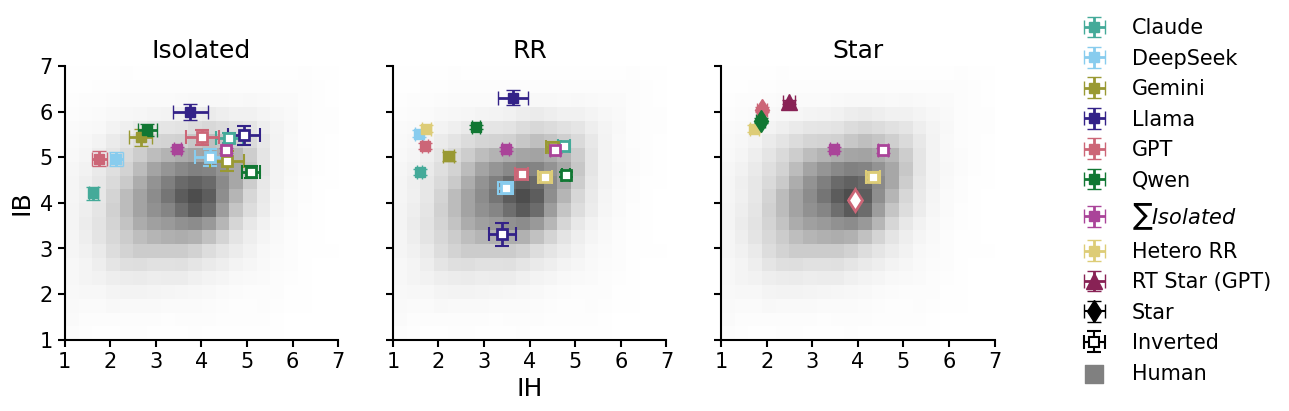

In [97]:
import scipy.stats as stats

# for CI 
ci_alpha = 0.05
n_comp_iso = 6*2*2
n_comp_rr = 7*2*2
n_comp_star = 3*2*2
n_comp_lincombo = 4
z_critical_iso = stats.norm.ppf(1 - ci_alpha / (2 * n_comp_iso))  # two-tailed
z_critical_rr = stats.norm.ppf(1 - ci_alpha / (2 * n_comp_rr))  # two-tailed
z_critical_star = stats.norm.ppf(1 - ci_alpha / (2 * n_comp_star))  # two-tailed
z_cirtical_lincombo = stats.norm.ppf(1 - ci_alpha / (2 * n_comp_lincombo))  # two-tailed

def compute_ci(sem, z_critical):
       margin_of_error = z_critical * sem
       return margin_of_error


# Plotting parameters
mker = 's'
text_size = 12*1.5
tick_size = 15
capsize = 5
markersize = 7.5
ci_width = 2
markerlinewidth = 2


# original with legend 
fig, ax = plt.subplots(nrows=1, ncols= 3, figsize=(12, 4), sharey=True, sharex=True)
# # for just the plots (no legend)
# fig, ax = plt.subplots(nrows=1, ncols= 3, figsize=(10.25, 5), sharey=True, sharex=True)

# titles
ax[0].set_title('Isolated', fontsize=text_size)
ax[1].set_title('RR',fontsize=text_size)
ax[2].set_title('Star',fontsize=text_size)
ax[0].set_ylabel('IB',fontsize=text_size)
ax[1].set_xlabel('IH',fontsize=text_size)

# human kde
[human_kde(human_df=h2, ax=a, alpha=0.7) for a in ax]

# Ticks and spines
[a.set_xlim(1, 7) for a in ax]
[a.set_xticks([1, 2, 3, 4, 5, 6, 7]) for a in ax]
[a.set_ylim(1, 7) for a in ax]
[a.set_yticks([1, 2, 3, 4, 5, 6, 7]) for a in ax]
[a.spines['top'].set_visible(False) for a in ax]
[a.spines['right'].set_visible(False) for a in ax]
[a.tick_params(axis='both', which='major', labelsize=tick_size)  for a in ax]


####################
#### plot singles
####################
single_models = ['Claude', 'DeepSeek', 'Gemini', 'Llama', 'GPT', 'Qwen']
# For each model, get data for both categories and plot
for m in single_models:
       # Get IH data for this model (and for inverted)
       ih_data = single_plot_df[(single_plot_df['plot_label'] == m) & (single_plot_df['category'] == 'IH')]
       ih_inverted  = single_plot_df[(single_plot_df['plot_label'] == 'Inverted ' + m) & (single_plot_df['category'] == 'IH')]
       ih_mean = ih_data['mean'].values[0]
       # Sem -> CI
       # ih_sem = ih_data['sem'].values[0]
       ih_sem = compute_ci(ih_data['sem'].values[0], z_critical_iso)
       ih_inverted_mean = ih_inverted['mean'].values[0] 
       # SEM-> CI
       # ih_inverted_sem = ih_inverted['sem'].values[0]
       ih_inverted_sem = compute_ci(ih_inverted['sem'].values[0], z_critical_iso)

       # Get IB data for this model (and for inverted)
       ib_data = single_plot_df[(single_plot_df['plot_label'] == m) & (single_plot_df['category'] == 'IB')]
       ib_inverted  = single_plot_df[(single_plot_df['plot_label'] == 'Inverted ' + m) & (single_plot_df['category'] == 'IB')]
       ib_mean = ib_data['mean'].values[0]
       # SEM-> CI
       # ib_sem = ib_data['sem'].values[0]
       ib_sem = compute_ci(ib_data['sem'].values[0], z_critical_iso)
       ib_inverted_mean = ib_inverted['mean'].values[0]
       # SEM -> CI
       # ib_inverted_sem = ib_inverted['sem'].values[0]
       ib_inverted_sem = compute_ci(ib_inverted['sem'].values[0], z_critical_iso)

       # Get color from our mapping
       color = tol_muted[m]

       # Use the same marker outline color but different fill based on inverted status

       ax[0].errorbar(
              ih_mean, ib_mean, elinewidth=ci_width,
              xerr=ih_sem, yerr=ib_sem, 
              fmt=mker, color=color, 
              markerfacecolor=color,    # Filled with color
              markeredgecolor=color,
              label=m, capsize=capsize,
              markersize=markersize)
       
       # Plot inverted with white fill and colored outline
       (plotline, _, _) = ax[0].errorbar(
              ih_inverted_mean, ib_inverted_mean,elinewidth=ci_width,
              xerr=ih_inverted_sem, yerr=ib_inverted_sem, 
              fmt=mker, color=color, markerfacecolor='white',  # White fill
              markeredgecolor=color,    # Color outline
              markeredgewidth=1.5,      # Thicker outline
              label=None, capsize=capsize,
              markersize=markersize
              )
       
       # Set the marker face color to none (transparent)
       #plotline.set_markerfacecolor('none')
       # Optionally, set the marker edge width for visibility
       plotline.set_markeredgewidth(markerlinewidth)



########################
#### plot Round Robins
########################
rr_topologies = ['Claude', 'DeepSeek', 'Gemini', 'Llama', 'GPT', 'Qwen', 'Hetero']

# For each model, get data for both categories and plot
for m in rr_topologies:
       
       # Get IH data for this model (and for inverted)
       ih_data = rr_plot_df[(rr_plot_df['plot_label'] == m) & (rr_plot_df['category'] == 'IH')]
       ih_inverted  = rr_plot_df[(rr_plot_df['plot_label'] == 'Inverted ' + m) & (rr_plot_df['category'] == 'IH')]
       ih_mean = ih_data['mean'].values[0]
       # SEM -> CI
       # ih_sem = ih_data['sem'].values[0]
       ih_sem = compute_ci(ih_data['sem'].values[0], z_critical_rr)
       ih_inverted_mean = ih_inverted['mean'].values[0] 
       # SEM -> CI
       # ih_inverted_sem = ih_inverted['sem'].values[0]
       ih_inverted_sem = compute_ci(ih_inverted['sem'].values[0], z_critical_rr)

       # Get IB data for this model (and for inverted)
       ib_data = rr_plot_df[(rr_plot_df['plot_label'] == m) & (rr_plot_df['category'] == 'IB')]
       ib_inverted  = rr_plot_df[(rr_plot_df['plot_label'] == 'Inverted ' + m) & (rr_plot_df['category'] == 'IB')]
       ib_mean = ib_data['mean'].values[0]
       # Size SEM -> CI
       ib_sem = compute_ci(ib_data['sem'].values[0], z_critical_rr)
       # ib_sem = ib_data['sem'].values[0]
       ib_inverted_mean = ib_inverted['mean'].values[0]
       # SEM -> CI
       # ib_inverted_sem = ib_inverted['sem'].values[0]
       ib_inverted_sem = compute_ci(ib_inverted['sem'].values[0], z_critical_rr)

       # Get color from our mapping
       color = tol_muted[m]

       # If Hetero, also plot in the third axis and label for legend
       if m == 'Hetero':
              ax[2].errorbar(
                     ih_mean, ib_mean,elinewidth=ci_width,
                     xerr=ih_sem, yerr=ib_sem, 
                     fmt=mker, color=color, 
                     markerfacecolor=color,    # Filled with color
                     markeredgecolor=color,
                     label='Hetero RR', capsize=capsize,
                     markersize=markersize
                     )
              (plotline, _, _) = ax[2].errorbar(
                     ih_inverted_mean, ib_inverted_mean,elinewidth=ci_width,
                     xerr=ih_inverted_sem, yerr=ib_inverted_sem, 
                     fmt=mker, color=color, markerfacecolor='white',  # White fill
                     markeredgecolor=color,    # Color outline
                     markeredgewidth=1.5,      # Thicker outline
                     label=None, capsize=capsize,
                     markersize=markersize
                     )
              
              # Set the marker face color to none (transparent)
              #plotline.set_markerfacecolor('none')
              # Optionally, set the marker edge width for visibility
              plotline.set_markeredgewidth(markerlinewidth)

       # Use the same marker outline color but different fill based on inverted status
       ax[1].errorbar(
              ih_mean, ib_mean,elinewidth=ci_width,
              xerr=ih_sem, yerr=ib_sem, 
              fmt=mker, color=color, 
              markerfacecolor=color,    # Filled with color
              markeredgecolor=color,
              label=None, capsize=capsize,
              markersize=markersize
              )
       
       # Plot inverted with white fill and colored outline
       (plotline, _, _) = ax[1].errorbar(
              ih_inverted_mean, ib_inverted_mean,elinewidth=ci_width,
              xerr=ih_inverted_sem, yerr=ib_inverted_sem, 
              fmt=mker, color=color, markerfacecolor='white',  # White fill
              markeredgecolor=color,    # Color outline
              markeredgewidth=1.5,      # Thicker outline
              label=None, capsize=capsize,
              markersize=markersize
              )
       # Set the marker face color to none (transparent)
       #plotline.set_markerfacecolor('none')
       # Optionally, set the marker edge width for visibility
       plotline.set_markeredgewidth(markerlinewidth)

########################
#### plot Star 
########################
star_marker = 'd'
star_marker_size = markersize * 1.5
star_capsize = capsize
star_topologies = ['RT Star (GPT)', 'GPT', 'Qwen']
star_markers = dict(zip(star_topologies, ['^', star_marker, star_marker]))  


for m in star_topologies:
       # Get IH data for this model (and for inverted)
       ih_data = star_plot_rr[(star_plot_rr['plot_label'] == m) & (star_plot_rr['category'] == 'IH')]
       ih_mean = ih_data['mean'].values[0]
       # SEM -> CI
       # ih_sem = ih_data['sem'].values[0]
       ih_sem = compute_ci(ih_data['sem'].values[0], z_critical_star)

       # Get IB data for this model (and for inverted)
       ib_data = star_plot_rr[(star_plot_rr['plot_label'] == m) & (star_plot_rr['category'] == 'IB')]
       ib_mean = ib_data['mean'].values[0]
       # SEM -> CI       
       # ib_sem = ib_data['sem'].values[0]
       ib_sem = compute_ci(ib_data['sem'].values[0], z_critical_star)


       marker_style = star_markers[m]
       if m == 'RT Star (GPT)':
              color = tol_muted['RT Star']
              # Use the same marker outline color but different fill based on inverted status
              ax[2].errorbar(
                     ih_mean, ib_mean,elinewidth=ci_width,
                     xerr=ih_sem, yerr=ib_sem, 
                     fmt=marker_style, color=color, 
                     markerfacecolor=color,    # Filled with color
                     markeredgecolor=color,
                     label=m, capsize=star_capsize,
                     markersize=star_marker_size
                     )
       else: 
              color = tol_muted[m]
              if m == 'GPT': 
                     # plot inverted
                     # Get IH data for this model (and for inverted)
                     ih_inverted  = star_plot_rr[(star_plot_rr['plot_label'] == 'Inverted ' + m) & (rr_plot_df['category'] == 'IH')]
                     ih_inverted_mean = ih_inverted['mean'].values[0]
                     ih_inverted_sem = ih_inverted['sem'].values[0]

                     # Get IB data for this model (and for inverted)
                     ib_inverted  = star_plot_rr[(star_plot_rr['plot_label'] == 'Inverted ' + m) & (rr_plot_df['category'] == 'IB')]
                     ib_inverted_mean = ib_inverted['mean'].values[0]
                     ib_inverted_sem = ib_inverted['sem'].values[0]

                     # Plot inverted with white fill and colored outline
                     (plotline, _, _) = ax[2].errorbar(
                            ih_inverted_mean, ib_inverted_mean,elinewidth=ci_width,
                            xerr=ih_inverted_sem, yerr=ib_inverted_sem, 
                            fmt=marker_style, color=color, markerfacecolor='white',  # White fill
                            markeredgecolor=color,    # Color outline
                            markeredgewidth=1.5,      # Thicker outline
                            label=None, capsize=star_capsize,
                            markersize=star_marker_size
                            )
                     # Set the marker face color to none (transparent)
                     #plotline.set_markerfacecolor('none')
                     # Optionally, set the marker edge width for visibility
                     plotline.set_markeredgewidth(markerlinewidth)

              # Use the same marker outline color but different fill based on inverted status
              ax[2].errorbar(
                     ih_mean, ib_mean,elinewidth=ci_width,
                     xerr=ih_sem, yerr=ib_sem, 
                     fmt=marker_style, color=color, 
                     markerfacecolor=color,    # Filled with color
                     markeredgecolor=color,
                     label=None, capsize=capsize,
                     markersize=1.5*markersize
                     )

####################
#### plot extras
####################
# General star 
ax[2].errorbar(
              8, 8,
              xerr=1e3, yerr=1e3, 
              fmt=star_marker, color='black', 
              markerfacecolor='black',    # Filled with color
              markeredgecolor='black',
              label='Star', capsize=star_capsize,
              markersize=star_marker_size
              )

######################################################
### Linear combination of singles (LinCombo) #########
######################################################
lc_ih_mean = lincombo_results_df[(lincombo_results_df['category']=='IH') & (lincombo_results_df['ggb_type']=='GGB')].mean_lc.values[0]
lc_ih_sem = lincombo_results_df[(lincombo_results_df['category']=='IH') & (lincombo_results_df['ggb_type']=='GGB')].sem_lc.values[0]
lc_ih_ic = compute_ci(lc_ih_sem, z_cirtical_lincombo)

lc_ib_mean = lincombo_results_df[(lincombo_results_df['category']=='IB') & (lincombo_results_df['ggb_type']=='GGB')].mean_lc.values[0]
lc_ib_sem = lincombo_results_df[(lincombo_results_df['category']=='IB') & (lincombo_results_df['ggb_type']=='GGB')].sem_lc.values[0]
lc_ib_ic = compute_ci(lc_ib_sem, z_cirtical_lincombo)

lc_ih_inv_mean = lincombo_results_df[(lincombo_results_df['category']=='IH') & (lincombo_results_df['ggb_type']=='GGB_inverted')].mean_lc.values[0]
lc_ih_inv_sem = lincombo_results_df[(lincombo_results_df['category']=='IH') & (lincombo_results_df['ggb_type']=='GGB_inverted')].sem_lc.values[0]
lc_ih_inv_ic = compute_ci(lc_ih_inv_sem, z_cirtical_lincombo)

lc_ib_inv_mean = lincombo_results_df[(lincombo_results_df['category']=='IB') & (lincombo_results_df['ggb_type']=='GGB_inverted')].mean_lc.values[0]
lc_ib_inv_sem = lincombo_results_df[(lincombo_results_df['category']=='IB') & (lincombo_results_df['ggb_type']=='GGB_inverted')].sem_lc.values[0]
lc_ib_inv_ic = compute_ci(lc_ib_inv_sem, z_cirtical_lincombo)

y_ib = 5.192746    
y_ib_error = 0.130093
x_ih = 2.323340    
x_ih_error = 0.154879
LC_color = tol_muted['pink']

ax[0].errorbar(
       lc_ih_mean, lc_ib_mean,elinewidth=ci_width,
       xerr=lc_ih_ic, yerr=lc_ib_ic, 
       fmt=mker, color=LC_color, markerfacecolor=LC_color,  # White fill
       markeredgecolor=LC_color,    # Color outline
       label=r'$\sum{Isolated}$', capsize=capsize,
       markersize=markersize
       )
ax[1].errorbar(
       lc_ih_mean, lc_ib_mean,elinewidth=ci_width,
       xerr=lc_ih_ic, yerr=lc_ib_ic, 
       fmt=mker, color=LC_color, markerfacecolor=LC_color,  # White fill
       markeredgecolor=LC_color,    # Color outline
       label=None, capsize=capsize,
       markersize=markersize
       )
ax[2].errorbar(
       lc_ih_mean, lc_ib_mean,elinewidth=ci_width,
       xerr=lc_ih_ic, yerr=lc_ib_ic, 
       fmt=mker, color=LC_color, markerfacecolor=LC_color,  # White fill
       markeredgecolor=LC_color,    # Color outline
       label=None, capsize=capsize,
       markersize=markersize
       )

(plotline, _, _)= ax[0].errorbar(
       lc_ih_inv_mean, lc_ib_inv_mean,elinewidth=ci_width,
       xerr=lc_ih_inv_ic, yerr=lc_ib_inv_ic, 
       fmt=mker, color=LC_color, markerfacecolor='white',  # White fill
       markeredgecolor=LC_color,    # Color outline
       label=None, capsize=capsize,
       markersize=markersize
       )
plotline.set_markeredgewidth(markerlinewidth)

(plotline, _, _)= ax[1].errorbar(
       lc_ih_inv_mean, lc_ib_inv_mean,elinewidth=ci_width,
       xerr=lc_ih_inv_ic, yerr=lc_ib_inv_ic, 
       fmt=mker, color=LC_color, markerfacecolor='white',  # White fill
       markeredgecolor=LC_color,    # Color outline
       label=None, capsize=capsize,
       markersize=markersize
       )
plotline.set_markeredgewidth(markerlinewidth)

(plotline, _, _)= ax[2].errorbar(
       lc_ih_inv_mean, lc_ib_inv_mean,elinewidth=ci_width,
       xerr=lc_ih_inv_ic, yerr=lc_ib_inv_ic, 
       fmt=mker, color=LC_color, markerfacecolor='white',  # White fill
       markeredgecolor=LC_color,    # Color outline
       label=None, capsize=capsize,
       markersize=markersize
       )
plotline.set_markeredgewidth(markerlinewidth)



# Add generic outside axis limits for legend
# Inverted
ax[2].errorbar(
       8, 8,
       xerr=1e3, yerr=1e3, 
       fmt=mker, color= 'black', markerfacecolor='white',  # White fill
       markeredgecolor= 'black',    # Color outline
       markeredgewidth=1.5,      # Thicker outline
       label='Inverted', capsize=capsize,
       markersize=markersize
       )

# General Human MARKER for legend
ax[2].scatter(
       8, 8, marker = 's', s=20*markersize,
       color= 'gray',
       label='Human')

## REORDER LEGEND (Human at the end)
# Collect handles from ALL subplots in the order you want
all_handles = []
all_labels = []

for i, a in enumerate(ax):
    handles, labels = a.get_legend_handles_labels()
    if i==2:
       desired_order = [1, 2, 3, 4, 0]
       handles = [handles[i] for i in desired_order]
       labels = [labels[i] for i in desired_order]
    all_handles.extend(handles)
    all_labels.extend(labels)
    

fig.legend(all_handles, all_labels, loc= 'center left',  #'upper center',        # Align by upper center
                bbox_to_anchor= (.95, 0.5), #(0.5, -0.16), # Position below axes (x=center, y=below)
                frameon=False, 
                fontsize=tick_size)
                
ax[0].set_aspect(1, share=True) # equal aspect ratio for all subplots




# # Reorder to put the square marker last
# desired_order = [0, 1, 2]  # or whatever order you want
# plt.legend([handles[i] for i in desired_order], 
#            [labels[i] for i in desired_order])


fig.savefig('figures/IBvIH.png.png', bbox_inches='tight', dpi = 300)

In [79]:
lincombo_results_df

,category,ggb_type,n_x,n_y,U,p_value,effect_size_r,mean_lc,std_lc,sem_lc
0,IB,GGB,7160,3363,9839800.0,0.00,0.15,5.174581,1.395612,0.016493
1,IB,GGB_inverted,3573,3383,6770010.5,0.00,0.10,5.155052,1.404692,0.023500
2,IH,GGB,5411,2644,10818554.5,0.00,0.42,3.473665,2.219893,0.030178
3,IH,GGB_inverted,2759,2706,3753740.5,0.71,0.00,4.550199,2.248659,0.042810


In [ ]:
lc_ih_mean = lincombo_results_df[(lincombo_results_df['category']=='IH') & (lincombo_results_df['ggb_type']=='GGB')].mean_x.values[0]


,category,ggb_type,n_x,n_y,U,p_value,effect_size_r,mean_lc,std_lc,sem_lc
1,IB,GGB_inverted,3573,3383,6770010.5,0.0,0.1,5.155052,1.404692,0.0235
